# Práctica 04: Análisis de Datos Exploratorio con Pyton y Jupiter Notebook en un Dataset de Productos de Amazon Store

**Programa de Estudios:** Ingeniería en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analítica de Datos para Negocios Digitales \
**Docente:** M.T.I Marco A. Ramírez Hernández \
**Periodo:** Mayo-Agosto 2026


### Unidad 2: Preparación de los Datos

**Nombre del Estudiante:** Karla Ivon Vargas Tavera \
**Matrícula:** 230094 \
**Grado y Grupo:** 9°A IEVND

<div style="background: linear-gradient(135deg, #FF69B4 0%, #232F3E 100%); padding: 30px; border-radius: 15px; text-align: center; margin-bottom: 20px;">
    <h1 style="color: white; font-size: 2.2em; margin: 0;">
        🛒 Productos de Amazon Store - Análisis Exploratorio de Datos Completo & Aprendizaje Automático Predictivo (ML)
    </h1>
    <p style="color: #FFD700; font-size: 1.1em; margin-top: 10px;">
        Predicción de Precios · Análisis de Categorías · Ingeniería de Características · Comparación de Modelos
    </p>
</div>

### ---

## 📋 Tabla de Contenidos

| # | Sección | Descripción |
|---|---|---|
| 1 | [Instalaciones & Carga de Dtos](#s1) | Liberias, carga del CVS, primeros comandos de estrctura |
| 2 | [Dicionario de Datos](#s2) | Explicación del contenido de columnas y calcular el % de datos faltantes |
| 3 | [Limpieza de Datos](#s3) | Aplicación de métodos básicos de limpieza (eliminácion duplicados, agrupación,datos nulos) |
| 4 | [ Ingenieria de Caracteristicas (Feature Engineering)](#s4) | características de texto, codificación de categorías, niveles de precios |
| 5 | [Análisis Univariado ](#s5) | Estudio individual de las variables mediante estadísticas descriptivas y visualizaciones. |
| 6 | [Análisis de Categorías ](#s6) | Exploración de variables categóricas, frecuencias y distribución por categorías. |
| 7 | [Análisis Bivariado y Multivariado](#s7) | Matriz de correlación de variables numéricas y mapas de calor. |
| 8 | [Planteamiento de Hipótesis](#s8) | Definición formal de las cuatro hipótesis estadísticas del proyecto de negocio. |
| 9 | [Pruebas de Hipótesis Estadísticas](#s9) | Aplicación de pruebas (Kruskal-Wallis, Mann-Whitney U y Spearman) y análisis de p-valores. |
| 10 | [Preprocesamiento para Machine Learning](#s10) | Selección de características, definición de la variable objetivo y codificación One-Hot. |
| 11 | [División del Dataset](#s11) | Segmentación de los datos en conjuntos de entrenamiento y prueba (Train/Test Split). |
| 12 | [Modelado de Regresión](#s12) | Configuración y entrenamiento de múltiples algoritmos predictivos. |
| 13 | [Evaluación de Modelos](#s13) | Pipeline de evaluación y comparación de rendimiento con métricas ($R^2$ y MAE). |
| 14 | [Interpretación de Resultados y Moneda](#s14) | Conversión inversa del error logarítmico para obtener la desviación real en Rupias (₹). |
| 15 | [Conclusiones del Negocio Digital](#s15) | Hallazgos predictivos finales y recomendaciones comerciales para Amazon. |

## 1. Instalaciones & Carga de Datos 🔧 <a id='s1'></a>

<div style="background: #f0f8ff; padding: 12px; border-left: 4px solid #FF9900; border-radius: 5px; color: #0066cc;">
    <b>Dataset:</b> Amazon India - Listado de Productos (1,436 productos entre Libros, Kindle, Deportes y más)<br>
    <b>Objetivo:</b> Predecir el precio del producto (INR) a partir de la categoría, longitud del nombre y disponibilidad.<br>
    <b>Fuente de Datos:</b> Datos obtenidos mediante web scraping de páginas de productos de Amazon.in.
</div>

In [1]:
# ==============================================================================
# SECTION 1 - Setup & Data Loading
# ==============================================================================

import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

#ML -  Machine Learning- Entrenamiento de modelos matematicos para predecir en este caso precios
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split


# Statistical Tests
from scipy.stats import mannwhitneyu, spearmanr, kruskal
print(f'✅ Pandas: {pd.__version__}')
print(f'✅ NumPy: {np.__version__}')
print('✅ Todas las librerías se cargaron correctamente.')

✅ Pandas: 2.3.3
✅ NumPy: 2.3.5
✅ Todas las librerías se cargaron correctamente.


In [2]:
# Load dataset
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')

print(f'📦 Shape: {df_raw.shape}')
print(f'📋 Columns: {df_raw.columns.tolist()}')

df_raw.head(3)


📦 Shape: (1456, 17)
📋 Columns: ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2. Diccionario de Datos del Data Frame. <a id= 's2'></a>

In [3]:
# Column dictionay
col_info = {
    'rl'              : 'URL del Producto en Amazon.in',
    'asin'            : 'Número Estandarizado de Identificación por Amazon (unique ID)',
    'name'            : 'Nombre o Título del Producto',
    'overview'        : 'Breve Reseña del Producto (mayoria vacio. [])',
    'price'           : 'Precio como string (e.g. "1,600.00")',
    'currency'        : 'Código de Divisa (todas en INR)',
    'availability'    : 'Texto del Status del Stock (Inventario)',
    'brand'           : 'Nombre de la Marca/Autor',
    'about_item'      : 'Detalles/Especificaciones (mayoria faltante)',
    'img_source'      : 'URLs de Imágenes del Producto',
    'description'     : 'Descripción detallada y completa (mayoría faltante)',
    'specifications'  : 'Especificaciones Técnicas',
    'primary_category': 'Categoría Principal (Libros, Kindle, Deportes...)',
    'category_1'      : 'Subcategoría de nivel 1',
    'category_2'      : 'Subcategoría de nivel 2',
    'category_3'      : 'Subcategoría de nivel 3',
    'breadcrumbs'     : 'Ruta de Categorías'
}

print('📖 Diccionario por columnas:')

for col, desc in col_info.items():
    missing_pct = df_raw[col].isnull().mean() * 100
    print(
    f'{col:20s} | '
    f'{desc[:45]:45s} | '
    f'Missing: {missing_pct:.0f}%'
    )

📖 Diccionario por columnas:
rl                   | URL del Producto en Amazon.in                 | Missing: 0%
asin                 | Número Estandarizado de Identificación por Am | Missing: 1%
name                 | Nombre o Título del Producto                  | Missing: 1%
overview             | Breve Reseña del Producto (mayoria vacio. []) | Missing: 1%
price                | Precio como string (e.g. "1,600.00")          | Missing: 24%
currency             | Código de Divisa (todas en INR)               | Missing: 25%
availability         | Texto del Status del Stock (Inventario)       | Missing: 34%
brand                | Nombre de la Marca/Autor                      | Missing: 2%
about_item           | Detalles/Especificaciones (mayoria faltante)  | Missing: 92%
img_source           | URLs de Imágenes del Producto                 | Missing: 1%
description          | Descripción detallada y completa (mayoría fal | Missing: 92%
specifications       | Especificaciones Técnicas      

## 3. Limpieza de Datos <a id= 's3'></a>

<div style="background: #fff8e1; padding: 12px; border-left: 4px solid #FF9900; border-radius: 5px; color: #0066cc;">
<b>Pasos clave para la limpieza:</b><br> 
· Pareseas el precio strings como "1,600.00" -> float 1600.0<br>
· Manejar los datos faltantes (prie: 24%, availability: 33%, description: 92%)<br>
· Estandarizar el texto de disponibilidad en categorias limpias<br>
· Eliminar duplicados

</div>

In [4]:
# ============================================================
# SECTION 3 — Data Cleaning
# ============================================================
df = df_raw.copy()

# ── Parse price ─────────────────────────────────────────────
def clean_price(p):
    if pd.isna(p): return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)

# ── Standardise availability ─────────────────────────────────
def clean_availability(a):
    if pd.isna(a): return 'Unknown'
    a = str(a).strip().lower()
    if 'in stock' in a:          return 'In Stock'
    if 'unavailable' in a:       return 'Unavailable'
    if '1 to 3' in a:            return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a: return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:      return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a: return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:    return 'Ships 1-3 days'
    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)

# ── Text length features ─────────────────────────────────────
df['name_length']  = df['name'].fillna('').str.len()
df['name_words']   = df['name'].fillna('').str.split().str.len()
df['has_brand']    = df['brand'].notna().astype(int)
df['has_desc']     = df['description'].notna().astype(int)
df['has_specs']    = df['specifications'].notna().astype(int)

# ── Duplicate check ──────────────────────────────────────────
dupes = df.duplicated(subset='asin').sum()
print(f'✅ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✅ Duplicate ASINs: {dupes}')
print(f'✅ Availability categories: {df["avail_clean"].value_counts().to_dict()}')
df[['name','price_clean','avail_clean','primary_category','name_length']].head(5)

✅ Price parsed: 1,095 / 1,456 products
✅ Duplicate ASINs: 15
✅ Availability categories: {'In Stock': 607, 'Unknown': 493, 'Ships 1-3 weeks': 121, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 81, 'Other': 23, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


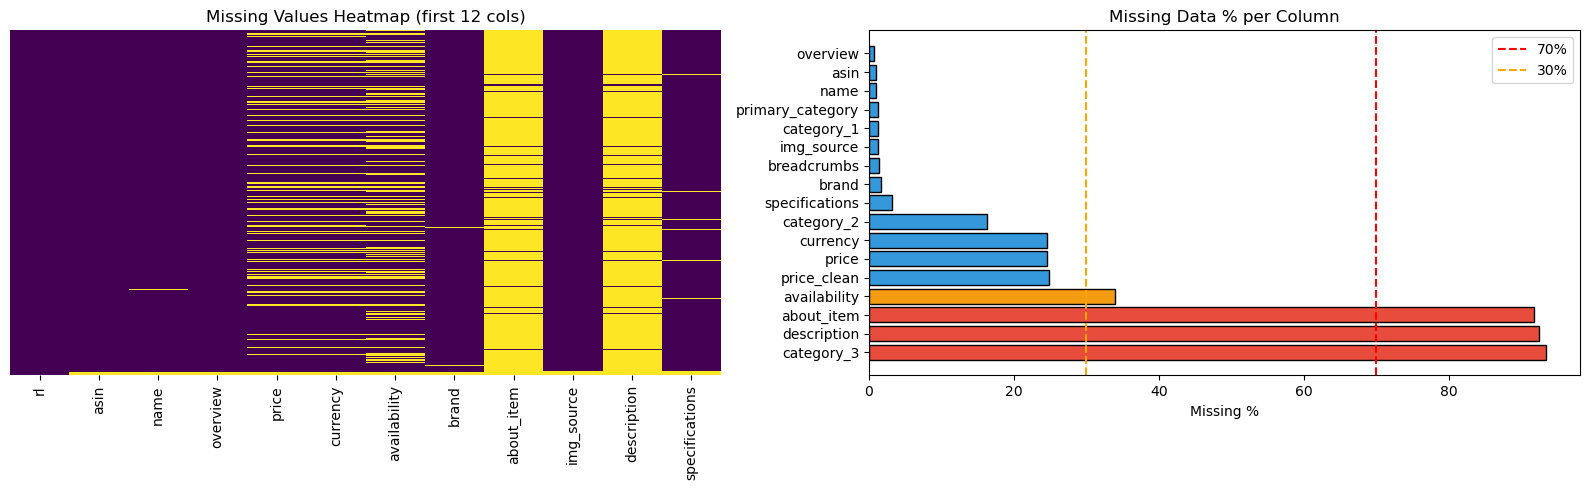

                  Missing Count  Missing Pct
category_3                 1360         93.4
description                1346         92.4
about_item                 1335         91.7
availability                493         33.9
price_clean                 361         24.8
price                       356         24.5
currency                    357         24.5
category_2                  237         16.3
specifications               46          3.2
brand                        23          1.6
breadcrumbs                  20          1.4
img_source                   19          1.3
category_1                   17          1.2
primary_category             17          1.2
name                         14          1.0
asin                         13          0.9
overview                     10          0.7


In [5]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct'  : (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(df[df.columns[:12]].isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values Heatmap (first 12 cols)')

mv = missing[missing['Missing Pct'] > 0]
colors_mv = ['#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
             for v in mv['Missing Pct']]
axes[1].barh(mv.index, mv['Missing Pct'], color=colors_mv, edgecolor='black')
axes[1].axvline(70, color='red', linestyle='--', label='70%')
axes[1].axvline(30, color='orange', linestyle='--', label='30%')
axes[1].set_xlabel('Missing %'); axes[1].set_title('Missing Data % per Column')
axes[1].legend()

plt.tight_layout(); plt.show()
print(missing[missing['Missing Count'] > 0].to_string())

## 4. Ingenieria de Caracteristicas (Feature Engineering) <a id='s4'></a>

<div style="background: #f0fff0; padding: 12px; border-left: 4px solid #27ae60; border-radius: 5px; color: #0066cc;">
<b>Ejemplo Cotidiano:</b> Un agente inmobiliario no soloutiliza los metros cuadrados brutos, sino que tambien considera la ubicación,la antogüedad y el estado. Nosotros hacemos lo mismo: extraemos informacion mas valiosa del texto sin procesar y las categorías..
</div>

In [6]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total features engineered: {len(df.columns)}')
print('\nPrice tier distribution:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)

✅ Total features engineered: 39

Price tier distribution:
price_tier
1_budget     105
2_low        285
3_mid        319
4_premium    260
5_luxury     126
Unknown      361


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5. Análisis Univariado 📊 <a id='s5'></a>

<div style="background:#eaf3ff; padding:12px; border-left:4px solid #2e86de; border-radius:5px;">
    <span style="color:#0066cc;">
        <b>Pregunta clave:</b> ¿Cómo es la distribución de precios? ¿Hay valores atípicos? ¿Los datos están sesgados?
    </span>
</div>

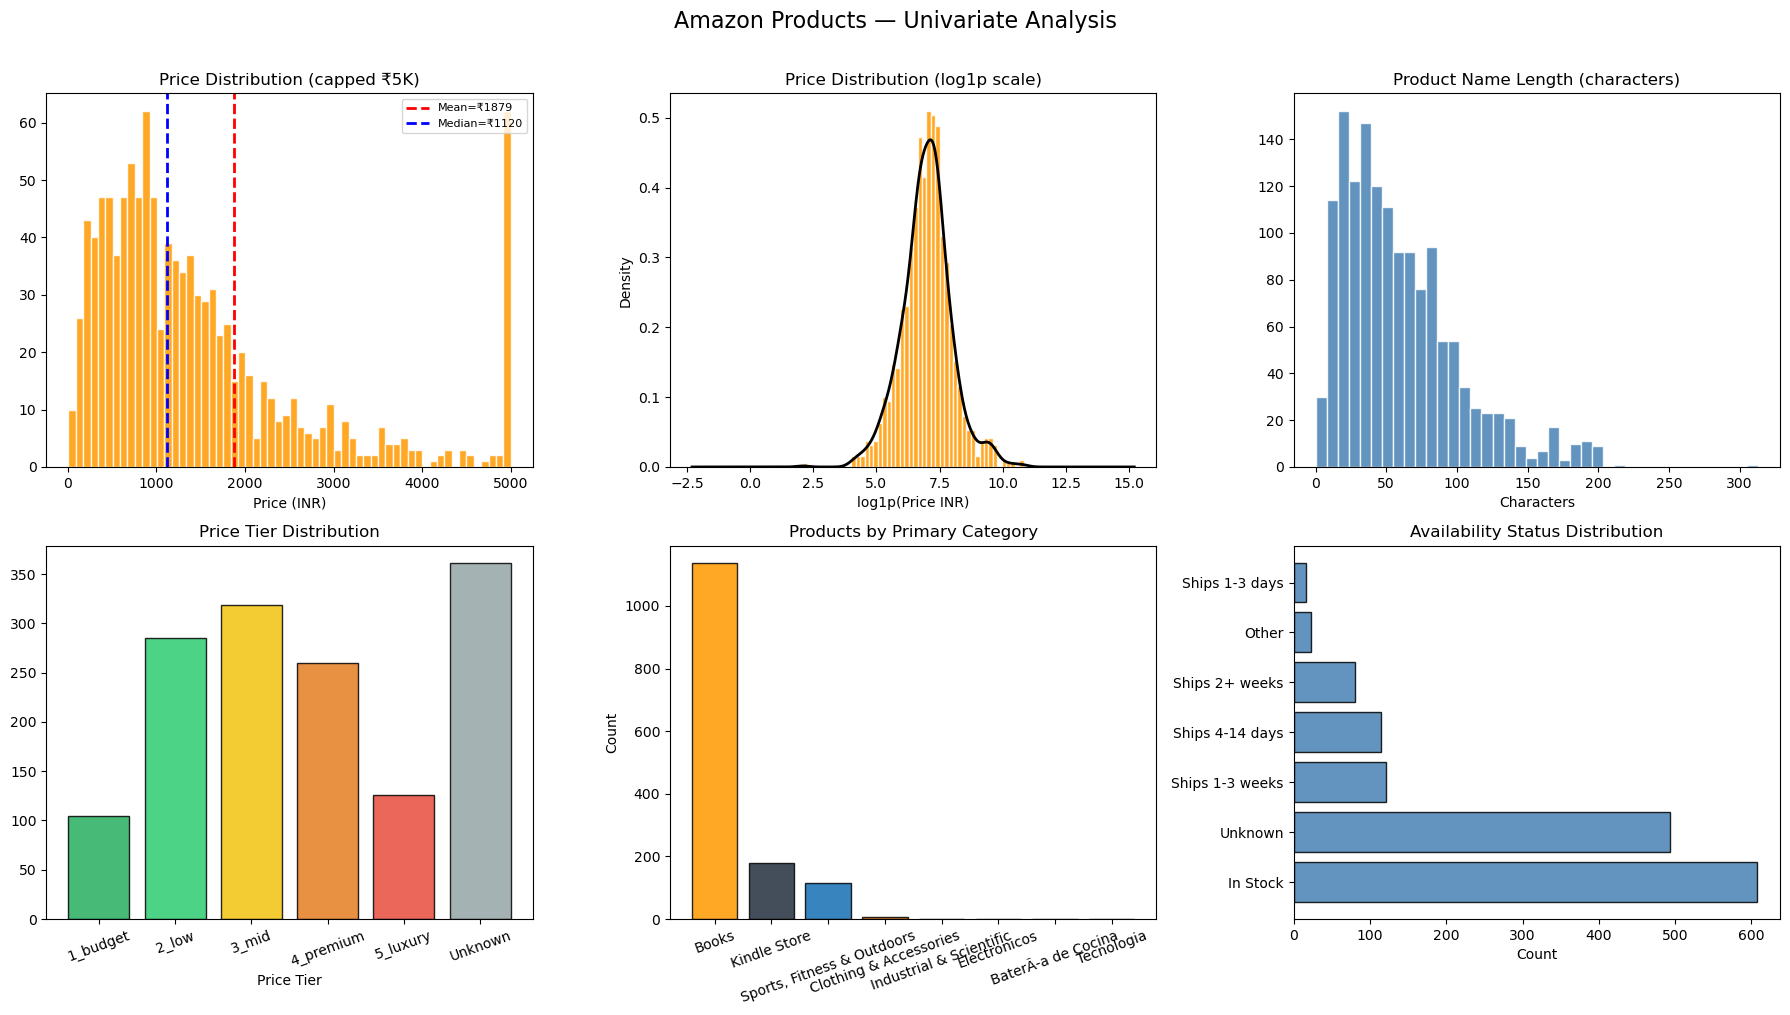

Shapiro-Wilk (log price, n=500): stat=0.9778, p=0.000001
Price is still non-normal after log transform

Price stats (INR):
count     1088.00
mean      1879.32
std       3338.48
min          7.00
25%        611.25
50%       1120.00
75%       1850.00
max      50555.00


In [7]:
from scipy.stats import shapiro

# ============================================================
# SECTION 4 — Univariate Analysis
# ============================================================
df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Price raw
axes[0,0].hist(df_priced['price_clean'].clip(upper=5000), bins=60,
               color='#FF9900', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_priced['price_clean'].mean(), color='red', linestyle='--',
                  lw=2, label=f'Mean=₹{df_priced["price_clean"].mean():.0f}')
axes[0,0].axvline(df_priced['price_clean'].median(), color='blue', linestyle='--',
                  lw=2, label=f'Median=₹{df_priced["price_clean"].median():.0f}')
axes[0,0].set_title('Price Distribution (capped ₹5K)')
axes[0,0].set_xlabel('Price (INR)')
axes[0,0].legend(fontsize=8)

# Price log
axes[0,1].hist(df_priced['log_price'], bins=50, color='#FF9900',
               edgecolor='white', alpha=0.85, density=True)
df_priced['log_price'].plot.kde(ax=axes[0,1], color='black', lw=2)
axes[0,1].set_title('Price Distribution (log1p scale)')
axes[0,1].set_xlabel('log1p(Price INR)')

# Name length
axes[0,2].hist(df['name_length'], bins=40, color='steelblue',
               edgecolor='white', alpha=0.85)
axes[0,2].set_title('Product Name Length (characters)')
axes[0,2].set_xlabel('Characters')

# Price tier
tier_counts = df['price_tier'].value_counts().sort_index()
tier_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#95a5a6']
axes[1,0].bar(tier_counts.index, tier_counts.values,
              color=tier_colors[:len(tier_counts)], edgecolor='black', alpha=0.85)
axes[1,0].set_title('Price Tier Distribution')
axes[1,0].set_xlabel('Price Tier')
axes[1,0].tick_params(axis='x', rotation=20)

# Primary category
cat_counts = df['primary_category'].value_counts()
axes[1,1].bar(cat_counts.index, cat_counts.values,
              color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
              edgecolor='black', alpha=0.85)
axes[1,1].set_title('Products by Primary Category')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=20)

# Availability
avail_counts = df['avail_clean'].value_counts()
axes[1,2].barh(avail_counts.index, avail_counts.values,
               color='steelblue', edgecolor='black', alpha=0.85)
axes[1,2].set_title('Availability Status Distribution')
axes[1,2].set_xlabel('Count')

plt.suptitle('Amazon Products — Univariate Analysis', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# Normality test
stat, p = shapiro(
    df_priced['log_price'].sample(
        min(500, len(df_priced)),
        random_state=42
    )
)

print(f'Shapiro-Wilk (log price, n={min(500, len(df_priced))}): stat={stat:.4f}, p={p:.6f}')
print(f'Price is {"normally distributed after log transform" if p > 0.05 else "still non-normal after log transform"}')

print(f'\nPrice stats (INR):')
print(df_priced['price_clean'].describe().round(2).to_string())

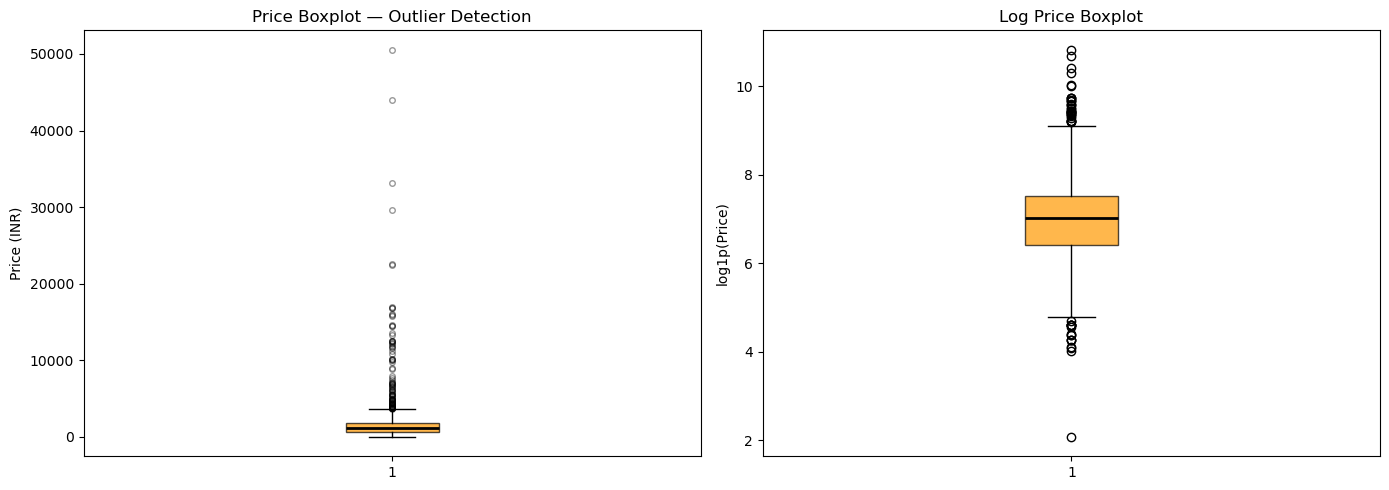

IQR method outliers: 93 (8.5%)
Price range (non-outlier): ₹-1247 – ₹3708

Top 10 most expensive products:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graphics Series)     29633.00                 

In [12]:
# Outlier analysis — boxplot and IQR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_priced['price_clean'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red'))
axes[0].set_title('Price Boxplot — Outlier Detection')
axes[0].set_ylabel('Price (INR)')

axes[1].boxplot(df_priced['log_price'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Log Price Boxplot')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout(); plt.show()

Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df_priced[(df_priced['price_clean'] < Q1 - 1.5*IQR) |
                      (df_priced['price_clean'] > Q3 + 1.5*IQR)]
print(f'IQR method outliers: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')
print(f'Price range (non-outlier): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')
print(f'\nTop 10 most expensive products:')
print(df_priced.nlargest(10, 'price_clean')[['name','price_clean','primary_category']].to_string(index=False))

## 6.Análisis de Categorías 🗂️ <a id='s6'></a>

<div style="background:#fff3cd; padding:12px; border-left:4px solid #ffc107; border-radius:5px;">
    <span style="color:#856404;">
        <b>Pregunta clave:</b> ¿Qué categorías tienen los precios más altos? ¿Qué subcategorías predominan? ¿Dónde se encuentra la mejor relación calidad-precio?
    </span>
</div>

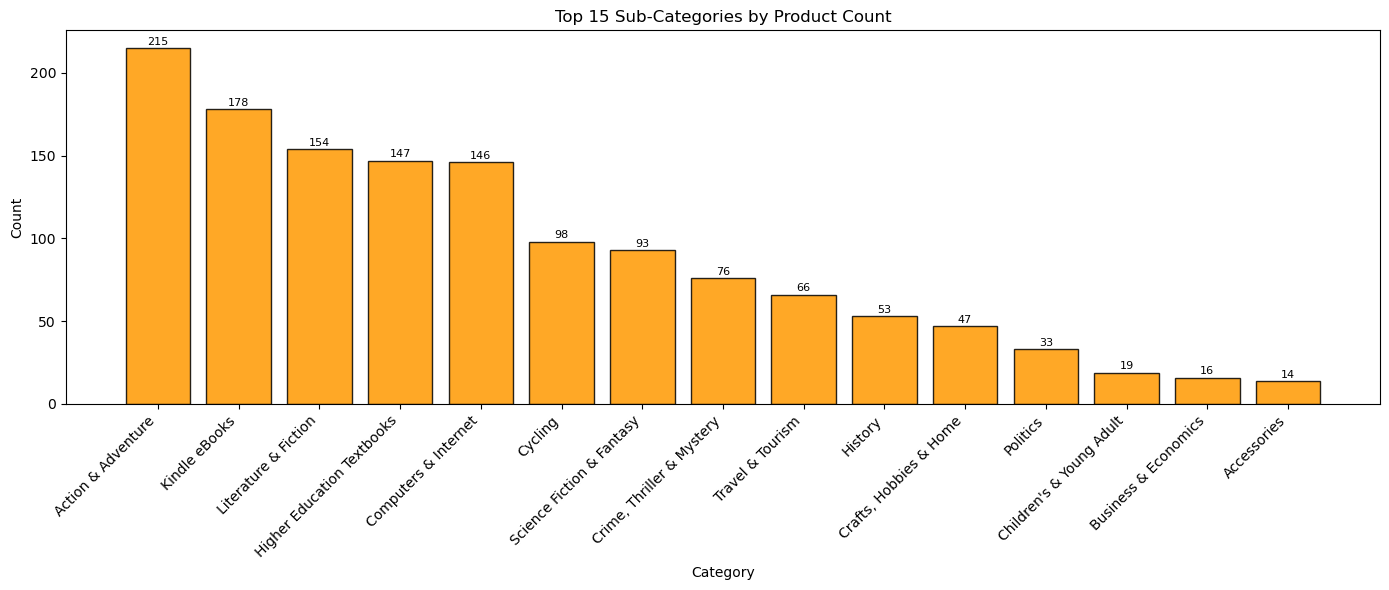

In [13]:
# ============================================================
# SECTION 5 — Category Analysis
# ============================================================
# Top 15 sub-categories by count
top15_cat1 = df['category_1'].value_counts().head(15)

plt.figure(figsize=(14, 6))
bars = plt.bar(top15_cat1.index, top15_cat1.values,
               color='#FF9900', edgecolor='black', alpha=0.85)
for bar, val in zip(bars, top15_cat1.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(val), ha='center', fontsize=8)
plt.title('Top 15 Sub-Categories by Product Count')
plt.xlabel('Category'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

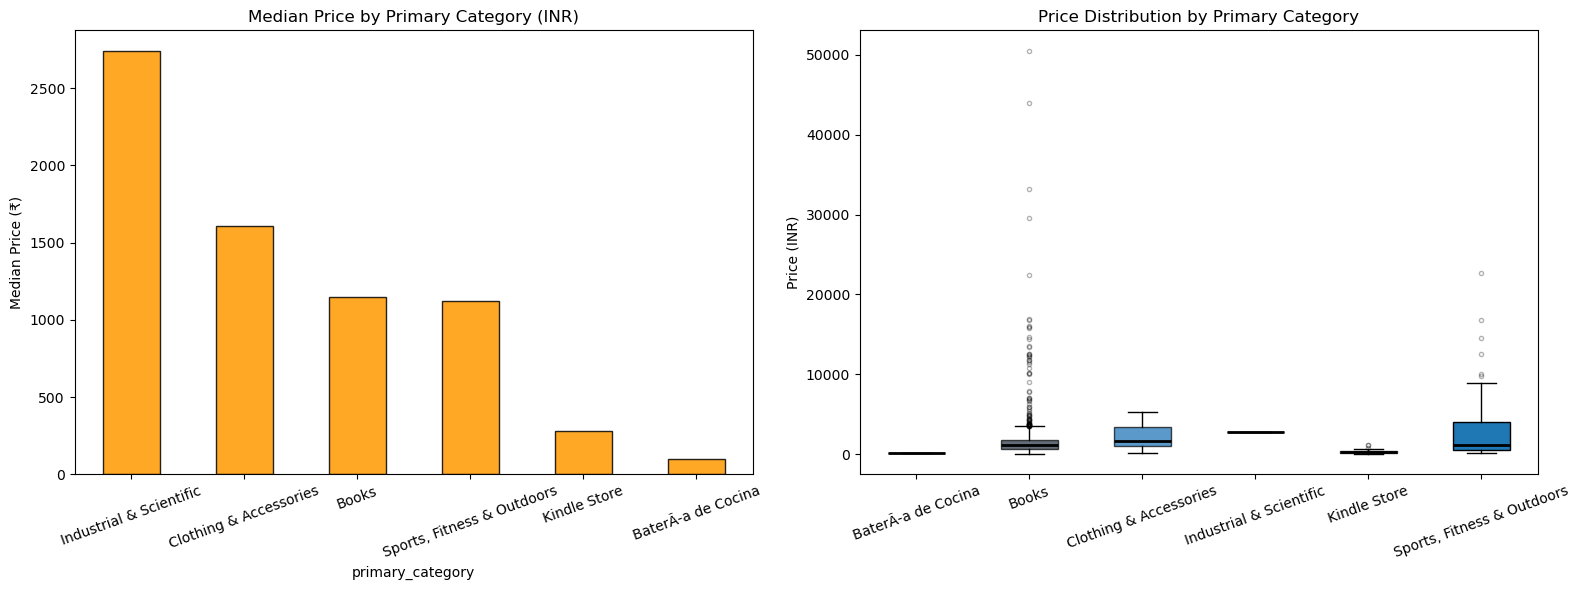

Price stats by primary category:
                              mean  median  count
primary_category                                 
BaterÃ­a de Cocina            99.0    99.0      1
Books                       1825.6  1145.0    955
Clothing & Accessories      2249.2  1606.5      6
Industrial & Scientific     2738.0  2738.0      1
Kindle Store                 350.0   281.4     30
Sports, Fitness & Outdoors  2907.9  1125.0     93


In [14]:
# Price by primary category
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Primary Category (INR)')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=20)

# Boxplot
cat_groups = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
              for c in cat_price.index]
bp = axes[1].boxplot(cat_groups, tick_labels=cat_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
colors_cat = ['#FF9900','#232F3E','#146EB4','#E47911','#999']
for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('Price Distribution by Primary Category')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()
print('Price stats by primary category:')
print(cat_price.to_string())

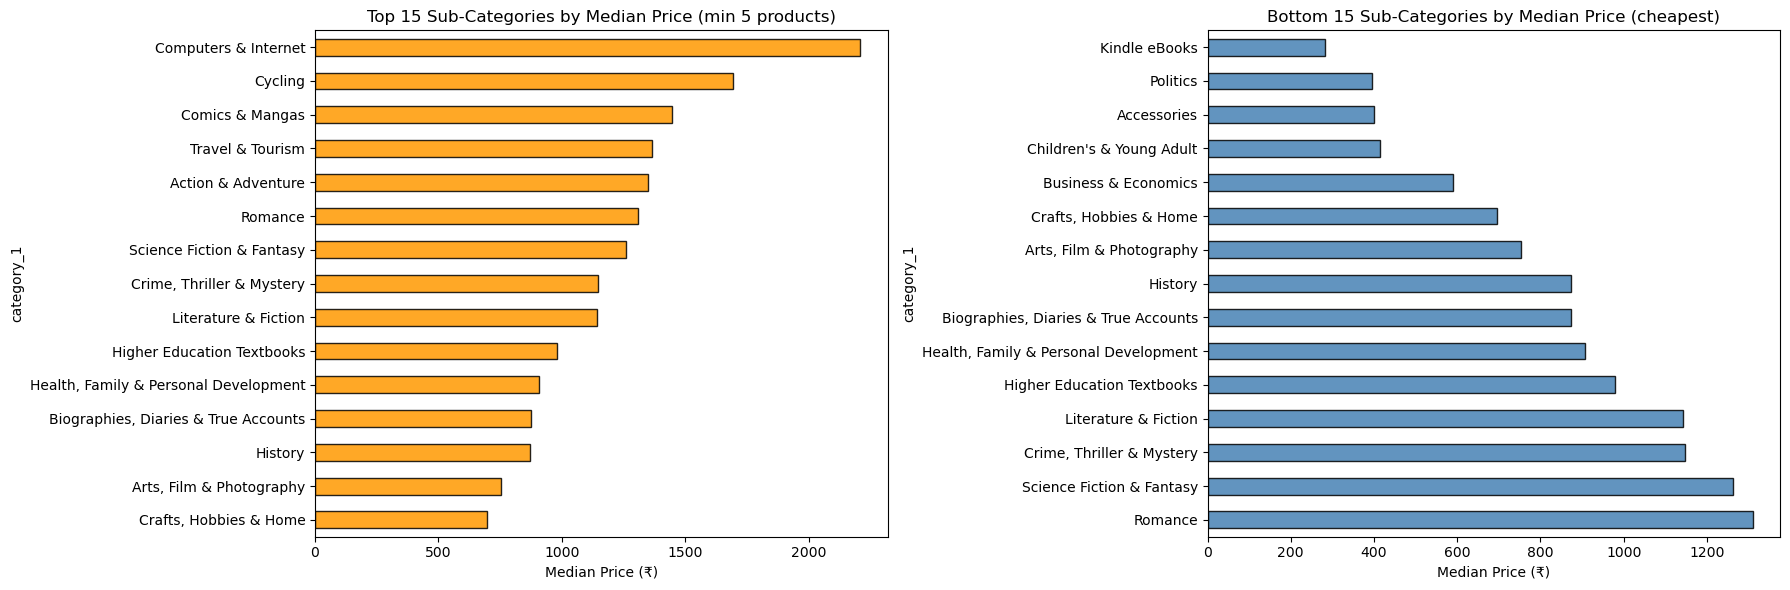

In [15]:
# Top 15 sub-categories by median price
top_cat1_price = (df_priced.groupby('category_1')['price_clean']
                  .agg(['median','count'])
                  .query('count >= 5')
                  .sort_values('median', ascending=False)
                  .head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Top 15 Sub-Categories by Median Price (min 5 products)')
axes[0].set_xlabel('Median Price (₹)')

# Bottom 15 (cheapest)
bottom_cat1 = (df_priced.groupby('category_1')['price_clean']
               .agg(['median','count'])
               .query('count >= 5')
               .sort_values('median')
               .head(15))
bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1], color='steelblue', edgecolor='black', alpha=0.85)
axes[1].set_title('Bottom 15 Sub-Categories by Median Price (cheapest)')
axes[1].set_xlabel('Median Price (₹)')

plt.tight_layout(); plt.show()

## 7.Análisis de Disponibilidad 📦 <a id='s7'></a>

<div style="background:#e8f5e9; padding:12px; border-left:4px solid #27ae60; border-radius:5px;">
    <span style="color:#1b5e20;">
        <b>Pregunta clave:</b> ¿Influye la disponibilidad en el precio? ¿Es más probable que los productos premium se agoten?
    </span>
</div>

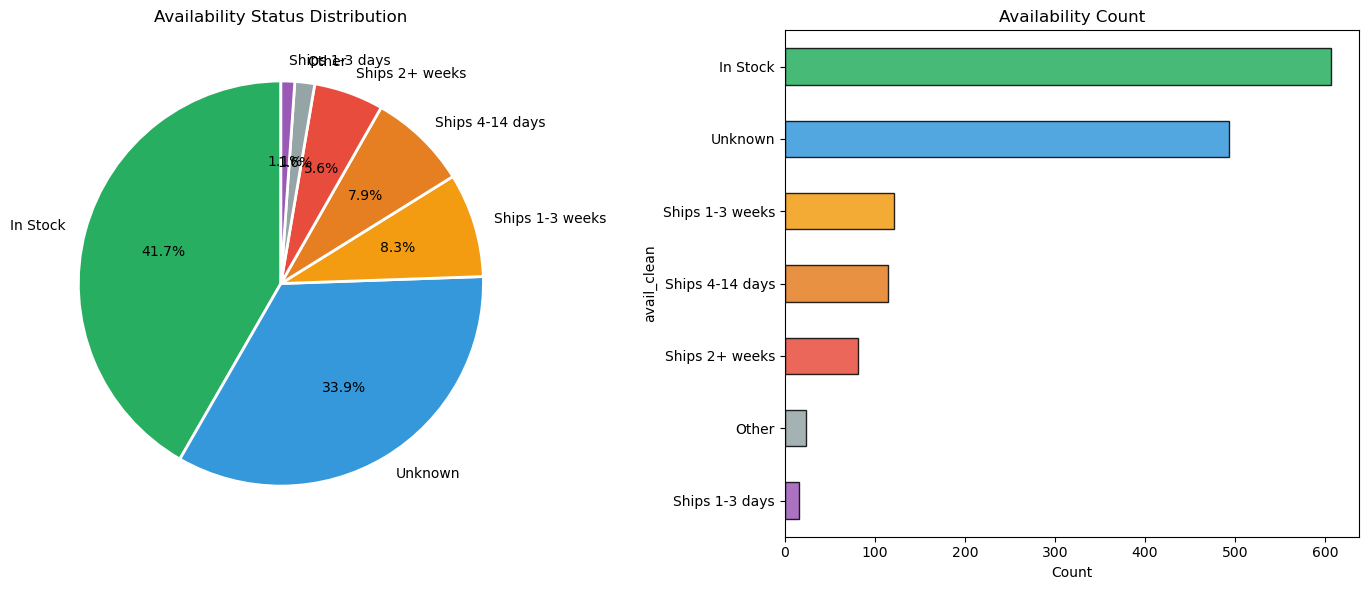

In [16]:
# ============================================================
# SECTION 6 — Availability Analysis
# ============================================================
avail_counts = df['avail_clean'].value_counts()
avail_colors = ['#27ae60','#3498db','#f39c12','#e67e22','#e74c3c','#95a5a6','#9b59b6','#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(avail_counts.values, labels=avail_counts.index,
            colors=avail_colors[:len(avail_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Availability Status Distribution')

avail_counts.sort_values().plot.barh(
    ax=axes[1], color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black', alpha=0.85)
axes[1].set_title('Availability Count')
axes[1].set_xlabel('Count')

plt.tight_layout(); plt.show()

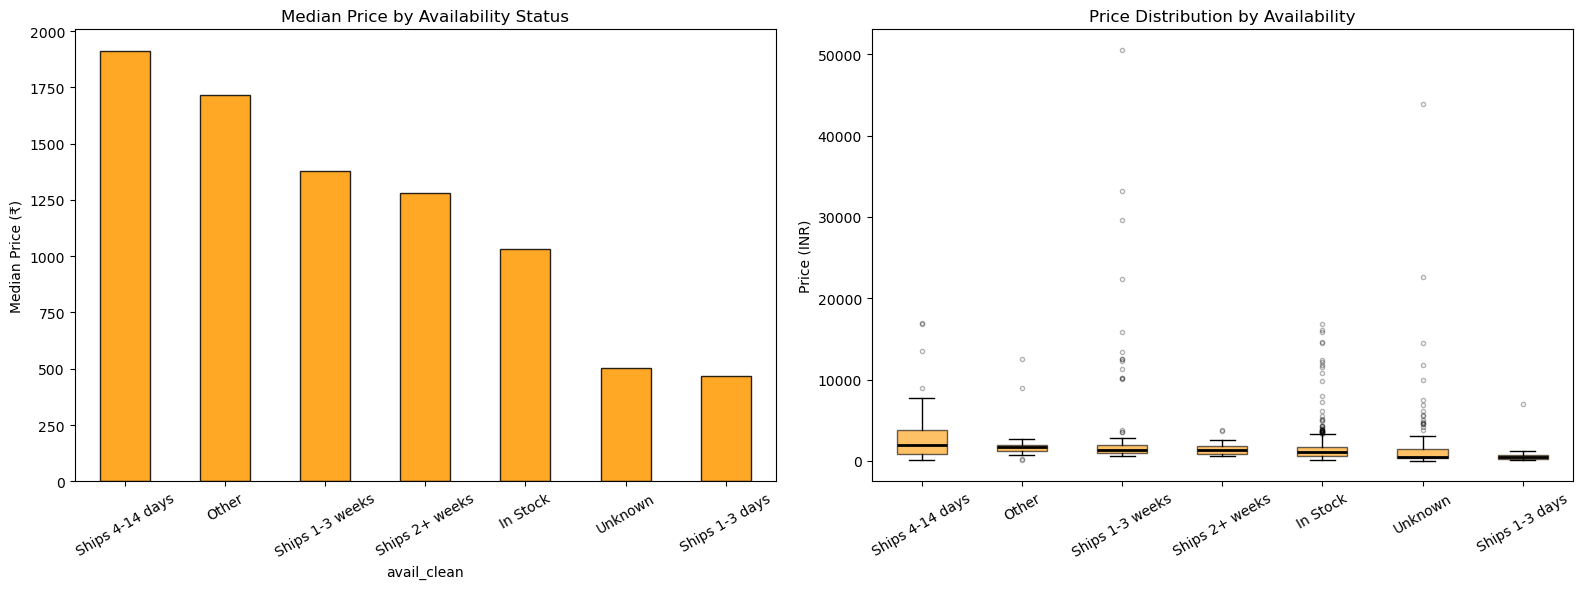

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1718.0  2347.0     21
Ships 1-3 weeks  1377.0  3231.6    121
Ships 2+ weeks   1279.0  1398.4     81
In Stock         1030.0  1490.5    599
Unknown           503.0  1879.4    135
Ships 1-3 days    469.0   874.9     16


In [17]:
# Price by availability status
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=30)

avail_groups = [df_priced[df_priced['avail_clean']==a]['price_clean'].dropna()
                for a in avail_price.index]

bp = axes[1].boxplot(avail_groups, tick_labels=avail_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))

for patch in bp['boxes']:
    patch.set_facecolor('#FF9900'); patch.set_alpha(0.6)

axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()

print('Price by availability:')
print(avail_price.to_string())

## 8.Análisis de Correlación y Bivariado 🔗 <a id='s8'></a>

<div style="background:#eaf3ff; padding:12px; border-left:4px solid #2e86de; border-radius:5px;">
    <span style="color:#0066cc;">
        <b>Pregunta clave:</b> ¿Qué características están más correlacionadas con el precio? ¿La longitud del nombre predice el precio?
    </span>
</div>

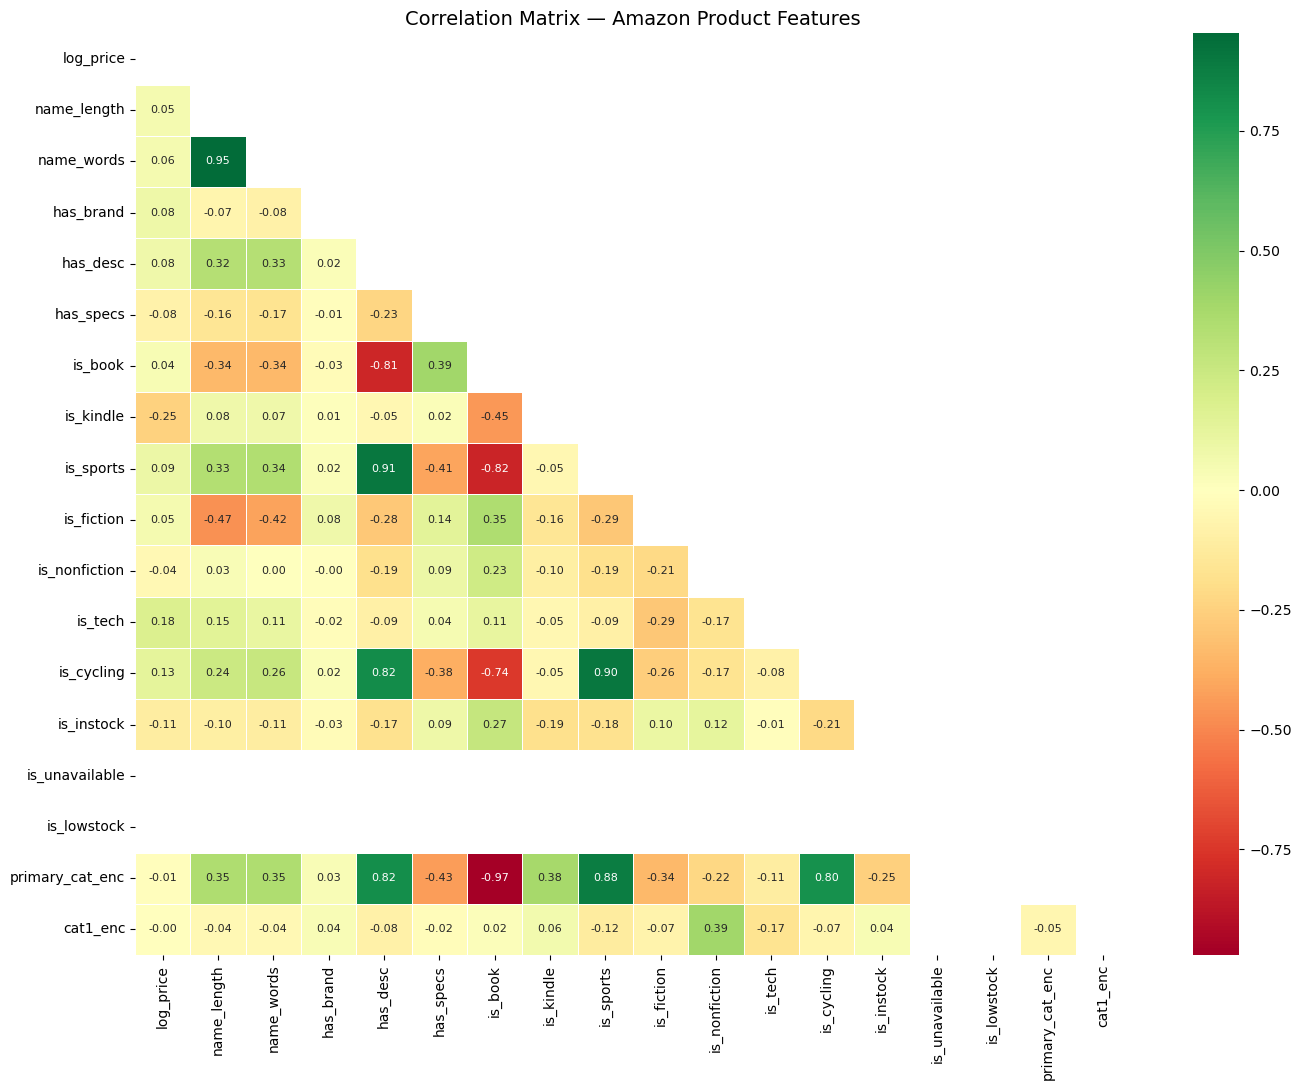

Top correlations with log_price:
is_tech            0.176878
is_cycling         0.126965
is_sports          0.092223
has_brand          0.083383
has_desc           0.081247
name_words         0.058193
is_fiction         0.054694
name_length        0.052726
is_book            0.040095
cat1_enc          -0.001384
primary_cat_enc   -0.011625
is_nonfiction     -0.042981
has_specs         -0.078544
is_instock        -0.111105
is_kindle         -0.245609
is_unavailable          NaN
is_lowstock             NaN


In [18]:
# ============================================================
# SECTION 7 — Correlation Analysis
# ============================================================
corr_cols = ['log_price','name_length','name_words','has_brand','has_desc',
             'has_specs','is_book','is_kindle','is_sports','is_fiction',
             'is_nonfiction','is_tech','is_cycling','is_instock',
             'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc']

corr = df_priced[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title('Correlation Matrix — Amazon Product Features', fontsize=14)
plt.tight_layout(); plt.show()

print('Top correlations with log_price:')
print(corr['log_price'].drop('log_price').sort_values(ascending=False).to_string())

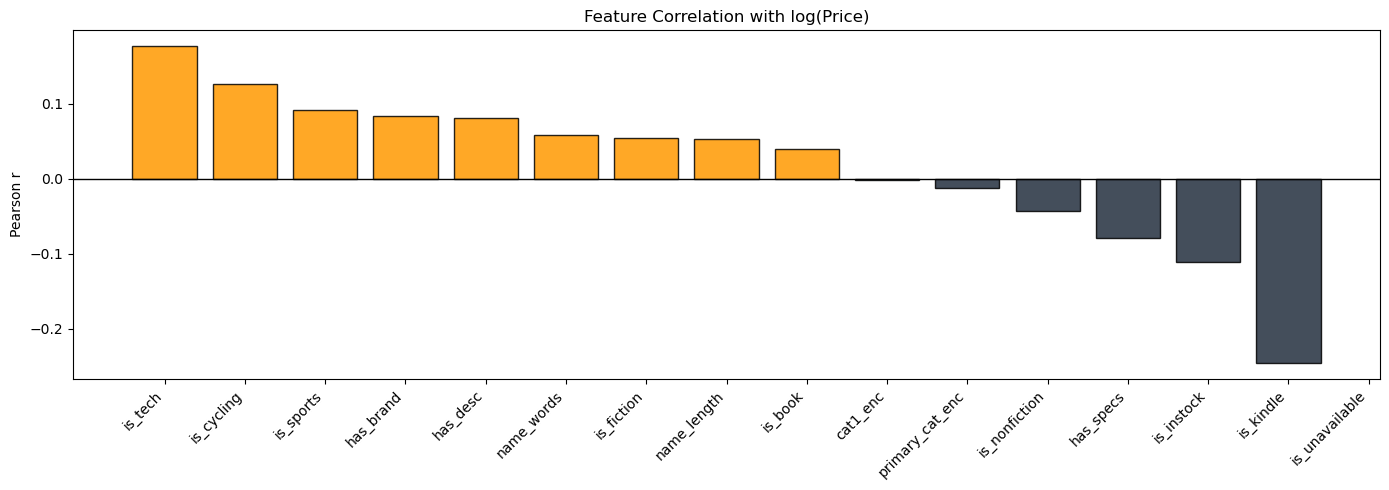

In [19]:
# Feature correlation bar chart
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)
plt.title('Feature Correlation with log(Price)')
plt.ylabel('Pearson r'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

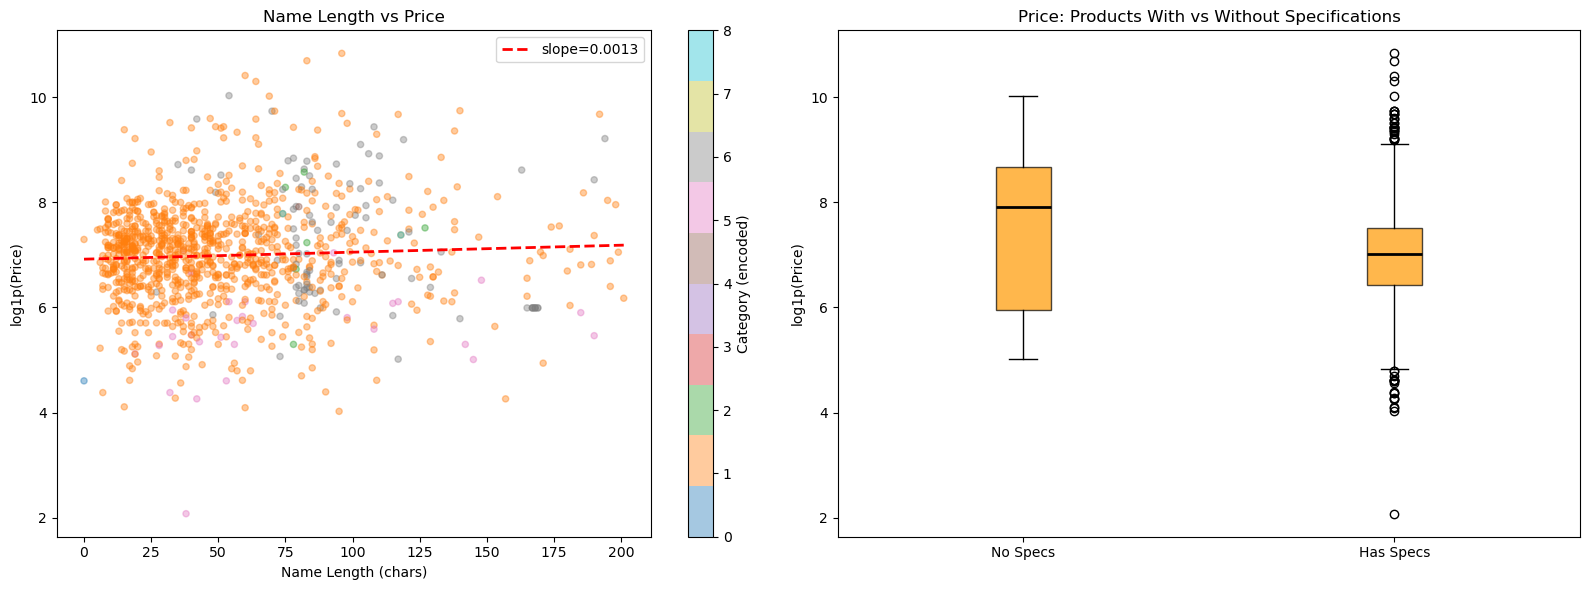

In [20]:
# Scatter: name length vs price
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(df_priced['name_length'], df_priced['log_price'],
                     c=df_priced['primary_cat_enc'], cmap='tab10',
                     alpha=0.4, s=20)
plt.colorbar(sc, ax=axes[0], label='Category (encoded)')
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[0].plot(x, m*x+b, 'r--', lw=2, label=f'slope={m:.4f}')

axes[0].set_xlabel('Name Length (chars)'); axes[0].set_ylabel('log1p(Price)')
axes[0].set_title('Name Length vs Price'); axes[0].legend()

# Price by has_specs
axes[1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                 np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                tick_labels=['No Specs','Has Specs'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))

axes[1].set_title('Price: Products With vs Without Specifications')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout(); plt.show()

## 9.  Prueba de hipótesis estadísticas 🧪 <a id='s9'></a>

<div style="background:#fff9db; padding:12px; border-left:4px solid #f59e0b; border-radius:5px;">
    <span style="color:#0254a3;">
        Utilizamos pruebas no paramétricas (Kruskal-Wallis, U de Mann-Whitney) porque el precio presenta una distribución muy asimétrica y no es normal. α = 0,05.
    </span>
</div>

| # | Hypothesis | Test |
| :--- | :--- | :--- |
| **H1** | El precio varía significativamente entre las categorías principales. | Kruskal-Wallis |
| **H2** | Los libros cuestan significativamente menos que los productos deportivos. | U de Mann-Whitney |
| **H3** | Los productos en stock tienen precios diferentes a los que no están disponibles. | U de Mann-Whitney |
| **H4** | La longitud del nombre está correlacionada positivamente con el precio. | Correlación de Spearman |
| **H5** | Los productos con especificaciones tienen un precio más elevado. | U de Mann-Whitney |

In [23]:
from scipy.stats import kruskal, mannwhitneyu, spearmanr

In [25]:
# ============================================================
# SECCIÓN 8 — Pruebas de Hipótesis
# ============================================================
alpha = 0.05

def mw_test(name, a, b, la, lb):
    a_clean = a.dropna()
    b_clean = b.dropna()
    
    print(f'{name}')
    # Imprime la mediana solo si hay datos, de lo contrario pone 0 para evitar errores
    mediana_a = a_clean.median() if len(a_clean) > 0 else 0
    mediana_b = b_clean.median() if len(b_clean) > 0 else 0
    
    print(f'  {la}: n={len(a_clean)}, mediana=₹{mediana_a:.0f}')
    print(f'  {lb}: n={len(b_clean)}, mediana=₹{mediana_b:.0f}')
    
    # Validación para evitar el error de SmallSampleWarning o muestras vacías (n=0)
    if len(a_clean) == 0 or len(b_clean) == 0:
        print("  ⚠️ ADVERTENCIA: No hay suficientes muestras en uno de los grupos para realizar la prueba.")
        print("  RESULTADO: ❌ NO RECHAZAR H0 (Datos insuficientes).")
        print()
        return None
        
    u, p = mannwhitneyu(a_clean, b_clean, alternative='two-sided')
    print(f'  Mann-Whitney U={u:.0f}, p={p:.6f}')
    print(f'  RESULTADO: {"✅ RECHAZAR H0 — Diferencia significativa." if p < alpha else "❌ NO RECHAZAR H0."}')
    print()
    return p

# H1: Precio entre categorías principales — Kruskal-Wallis
cat_groups_kw = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
                 for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category']==c]) >= 5]
cat_labels_kw = [c for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category']==c]) >= 5]

h1, p1 = kruskal(*cat_groups_kw)
print(f'H1: Precio entre Categorías Principales — Kruskal-Wallis')
for label, g in zip(cat_labels_kw, cat_groups_kw):
    print(f'  {label:35s}: n={len(g)}, mediana=₹{g.median():.0f}')
print(f'  H={h1:.4f}, p={p1:.6f}')
print(f'  RESULTADO: {"✅ RECHAZAR H0 — El precio difiere entre categorías." if p1 < alpha else "❌ NO RECHAZAR H0."}')
print()

# H2: Libros vs Deportes
p2 = mw_test('H2: Precio de Libros vs Productos Deportivos',
             df_priced[df_priced['is_book']==1]['price_clean'],
             df_priced[df_priced['is_sports']==1]['price_clean'],
             'Libros', 'Deportes')

# H3: En Stock vs No Disponible
p3 = mw_test('H3: Precio de Productos en Stock vs No Disponibles',
             df_priced[df_priced['is_instock']==1]['price_clean'],
             df_priced[df_priced['is_unavailable']==1]['price_clean'],
             'En Stock', 'No Disponible')

# H4: Longitud del nombre vs precio — Spearman
rho4, p4 = spearmanr(df_priced['name_length'], df_priced['price_clean'])
print(f'H4: Longitud del Nombre vs Precio — Correlación de Spearman')
print(f'  rho={rho4:.4f}, p={p4:.6f}')
print(f'  RESULTADO: {"✅ RECHAZAR H0 — Correlación significativa." if p4 < alpha else "❌ NO RECHAZAR H0."}')
print()

# H5: Con cookies vs sin especificaciones
p5 = mw_test('H5: Productos Con vs Sin Especificaciones',
             df_priced[df_priced['has_specs']==1]['price_clean'],
             df_priced[df_priced['has_specs']==0]['price_clean'],
             'Con Specs', 'Sin Specs')

H1: Precio entre Categorías Principales — Kruskal-Wallis
  Books                              : n=955, mediana=₹1145
  Sports, Fitness & Outdoors         : n=93, mediana=₹1125
  Kindle Store                       : n=30, mediana=₹281
  Clothing & Accessories             : n=6, mediana=₹1606
  H=55.8663, p=0.000000
  RESULTADO: ✅ RECHAZAR H0 — El precio difiere entre categorías.

H2: Precio de Libros vs Productos Deportivos
  Libros: n=955, mediana=₹1145
  Deportes: n=93, mediana=₹1125
  Mann-Whitney U=40247, p=0.135443
  RESULTADO: ❌ NO RECHAZAR H0.

H3: Precio de Productos en Stock vs No Disponibles
  En Stock: n=599, mediana=₹1030
  No Disponible: n=0, mediana=₹0
  ⚠️ ADVERTENCIA: No hay suficientes muestras en uno de los grupos para realizar la prueba.
  RESULTADO: ❌ NO RECHAZAR H0 (Datos insuficientes).

H4: Longitud del Nombre vs Precio — Correlación de Spearman
  rho=0.0376, p=0.214779
  RESULTADO: ❌ NO RECHAZAR H0.

H5: Productos Con vs Sin Especificaciones
  Con Specs: n=1065, 

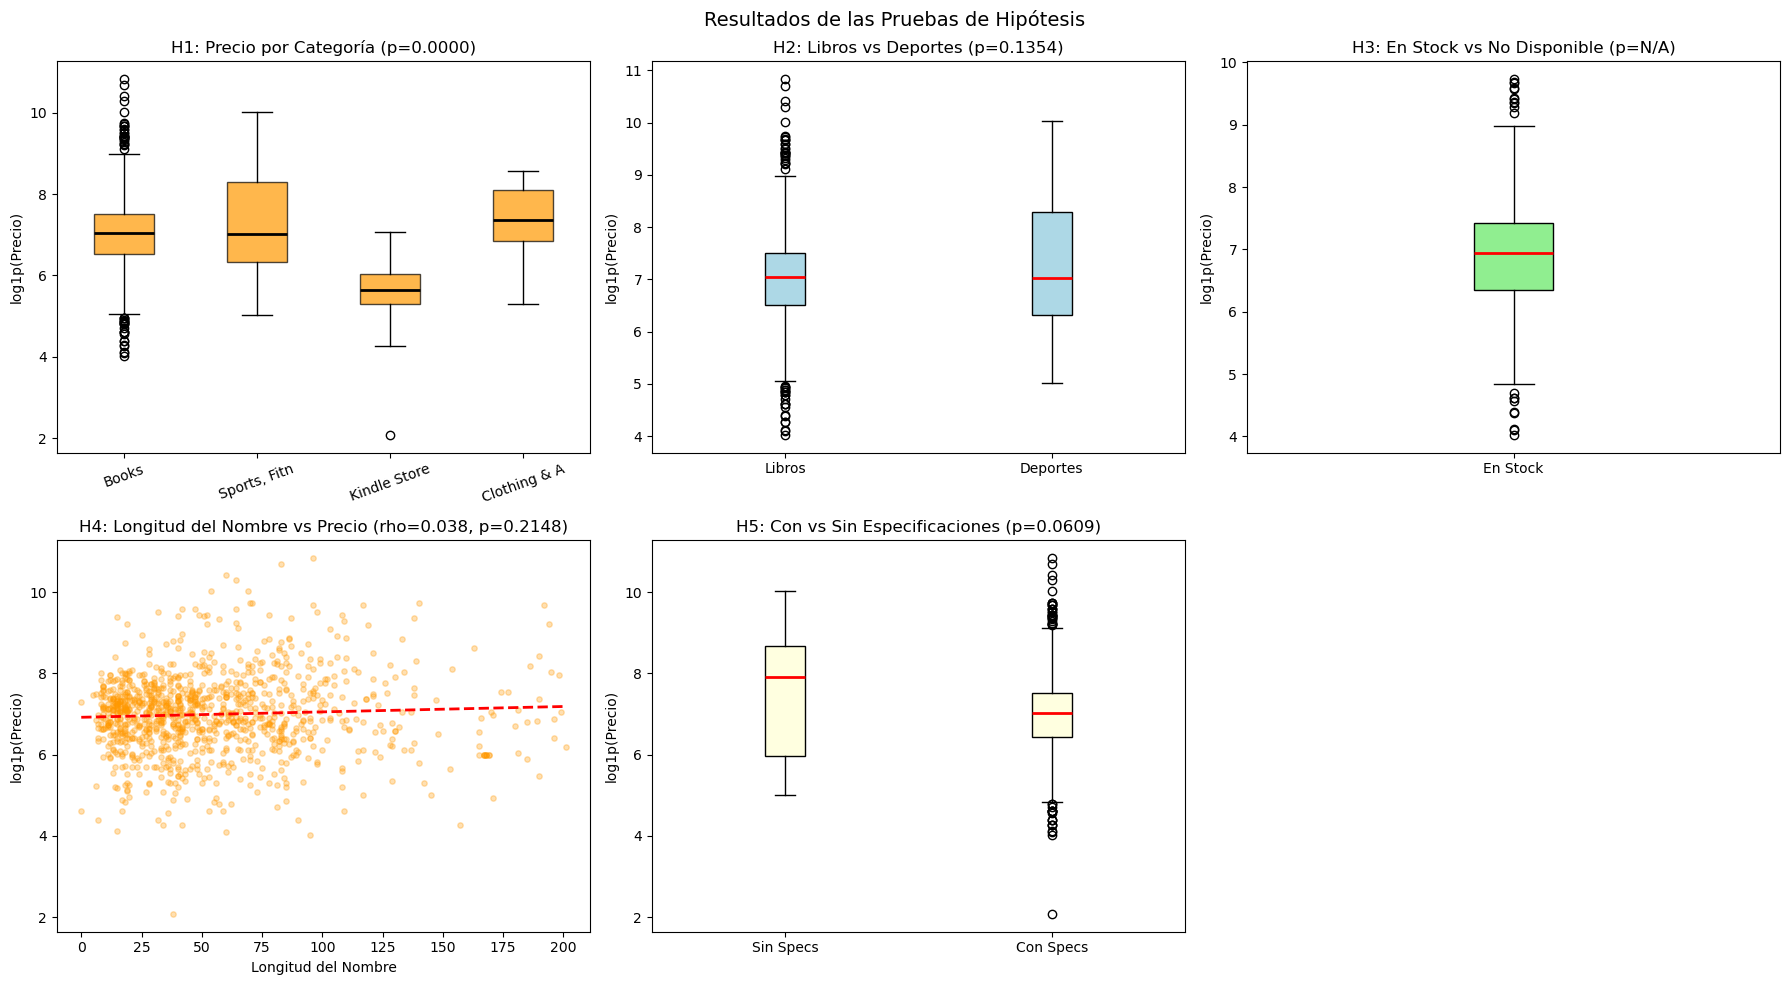

In [26]:
# Visualizar los resultados de las hipótesis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# H1
axes[0,0].boxplot([np.log1p(g) for g in cat_groups_kw],
                  tick_labels=[l[:12] for l in cat_labels_kw], patch_artist=True,
                  boxprops=dict(facecolor='#FF9900', alpha=0.7),
                  medianprops=dict(color='black', lw=2))
axes[0,0].set_title(f'H1: Precio por Categoría (p={p1:.4f})')
axes[0,0].set_ylabel('log1p(Precio)')
axes[0,0].tick_params(axis='x', rotation=20)

# H2
axes[0,1].boxplot([np.log1p(df_priced[df_priced['is_book']==1]['price_clean'].dropna()),
                   np.log1p(df_priced[df_priced['is_sports']==1]['price_clean'].dropna())],
                  tick_labels=['Libros','Deportes'], patch_artist=True,
                  boxprops=dict(facecolor='lightblue'),
                  medianprops=dict(color='red', lw=2))
axes[0,1].set_title(f'H2: Libros vs Deportes (p={p2:.4f})')
axes[0,1].set_ylabel('log1p(Precio)')

# H3 - Corregido para manejar el grupo vacío sin datos
h3_data_1 = np.log1p(df_priced[df_priced['is_instock']==1]['price_clean'].dropna())
h3_data_2 = np.log1p(df_priced[df_priced['is_unavailable']==1]['price_clean'].dropna())

# Si el segundo grupo está vacío, graficamos solo el primero para evitar errores
if len(h3_data_2) == 0:
    axes[0,2].boxplot([h3_data_1], tick_labels=['En Stock'], patch_artist=True,
                      boxprops=dict(facecolor='lightgreen'),
                      medianprops=dict(color='red', lw=2))
else:
    axes[0,2].boxplot([h3_data_1, h3_data_2], tick_labels=['En Stock','No Disponible'], patch_artist=True,
                      boxprops=dict(facecolor='lightgreen'),
                      medianprops=dict(color='red', lw=2))

texto_p3 = "N/A" if p3 is None else f"{p3:.4f}"
axes[0,2].set_title(f'H3: En Stock vs No Disponible (p={texto_p3})')
axes[0,2].set_ylabel('log1p(Precio)')

# H4
axes[1,0].scatter(df_priced['name_length'], df_priced['log_price'],
                  alpha=0.3, color='#FF9900', s=15)
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[1,0].plot(x, m*x+b, 'r--', lw=2)
axes[1,0].set_title(f'H4: Longitud del Nombre vs Precio (rho={rho4:.3f}, p={p4:.4f})')
axes[1,0].set_xlabel('Longitud del Nombre')
axes[1,0].set_ylabel('log1p(Precio)')

# H5
axes[1,1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean'].dropna()),
                   np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'].dropna())],
                  tick_labels=['Sin Specs','Con Specs'], patch_artist=True,
                  boxprops=dict(facecolor='lightyellow'),
                  medianprops=dict(color='red', lw=2))
texto_p5 = "N/A" if p5 is None else f"{p5:.4f}"
axes[1,1].set_title(f'H5: Con vs Sin Especificaciones (p={texto_p5})')
axes[1,1].set_ylabel('log1p(Precio)')

# Ocultar el último recuadro vacío
axes[1,2].set_visible(False)

plt.suptitle('Resultados de las Pruebas de Hipótesis', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Definición de problemas de aprendizaje automático 🎯 <a id='s10'></a>

<div style="background:#eef4fb; padding:12px; border-left:4px solid #4a90e2; border-radius:5px;">
    <span style="color:#0056b3;">
Tarea: Predecir el precio del producto (en escala logarítmica) a partir de la categoría, la longitud del nombre, la disponibilidad y los indicadores de características.

¿Por qué usar la escala logarítmica? El precio original presenta una fuerte asimetría positiva. La transformación lo hace más normal y evita que los valores atípicos costosos dominen la función de pérdida.
    </span>
</div>

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

✅ ML dataset shape : (1088, 20)
✅ Features         : 18

Train: 870 | Test: 218


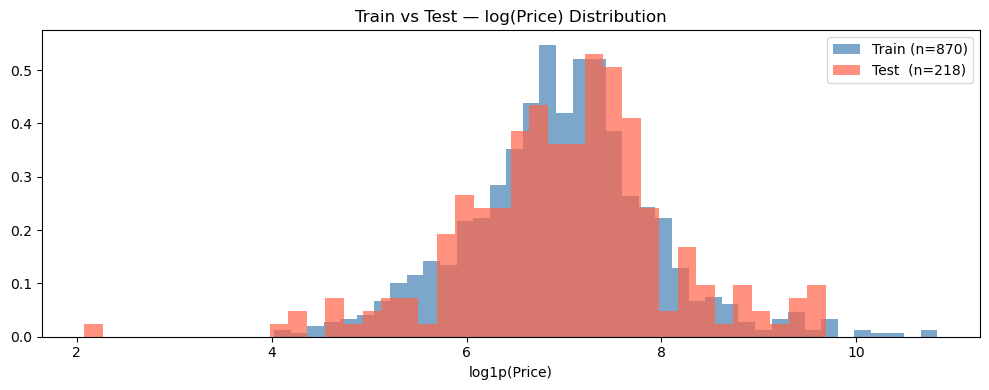

✅ Distributions look similar — good split!


In [61]:
# ============================================================
# SECTION 9 — ML Problem Framing
# ============================================================
FEATURE_COLS = [
    'name_length', 'name_words', 'has_brand', 'has_desc', 'has_specs',
    'is_book', 'is_kindle', 'is_sports',
    'is_fiction', 'is_nonfiction', 'is_tech', 'is_cycling',
    'is_instock', 'is_unavailable', 'is_lowstock',
    'primary_cat_enc', 'cat1_enc', 'avail_enc',
]

TARGET = 'log_price'

df_ml = df_priced[FEATURE_COLS + [TARGET, 'price_clean']].dropna().copy()
print(f'✅ ML dataset shape : {df_ml.shape}')
print(f'✅ Features         : {len(FEATURE_COLS)}')

X = df_ml[FEATURE_COLS]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nTrain: {len(X_train):,} | Test: {len(X_test):,}')

# Visualise split
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_train, bins=40, color='steelblue', alpha=0.7, label=f'Train (n={len(y_train)})', density=True)
ax.hist(y_test,  bins=40, color='tomato',    alpha=0.7, label=f'Test  (n={len(y_test)})',  density=True)
ax.set_title('Train vs Test — log(Price) Distribution')
ax.set_xlabel('log1p(Price)'); ax.legend()
plt.tight_layout(); plt.show()
print('✅ Distributions look similar — good split!')

## 11. Marco de selección de modelos 🧠 <a id='s11'></a>



| Modelo | Ventajas | Desventajas | Uso Principal |
|----------|----------|-------------|---------------|
| Regresión Lineal | Rápida y fácil de interpretar | Asume relaciones lineales | Modelo base |
| Regresión Ridge | Reduce la multicolinealidad | Sigue siendo lineal | Variables correlacionadas |
| Regresión Lasso | Selección automática de variables | Puede eliminar variables útiles | Datos con muchas características |
| Random Forest | Robusto y capaz de modelar relaciones no lineales | Menos interpretable | Patrones complejos |
| XGBoost / GBM | Alta precisión y rendimiento | Requiere ajuste de parámetros | Datos tabulares |

### Métricas de Evaluación

- **MAE:** Error Absoluto Medio (menor = mejor).
- **RMSE:** Raíz del Error Cuadrático Medio (penaliza errores grandes).
- **R²:** Variabilidad explicada por el modelo (mayor = mejor).
- **MAE (₹):** Error expresado en rupias indias para interpretación de negocio.

In [30]:
# ============================================================
# SECTION 10 — Evaluation Helpers
# ============================================================
results = {}

def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae_inr = mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))
    print(f'  📊 {name}:')
    print(f'     MAE (log)  = {mae:.4f}  |  MAE (₹) = ₹{mae_inr:,.0f}')
    print(f'     RMSE (log) = {rmse:.4f}  |  R²      = {r2:.4f}')
    results[name] = {'MAE_log': round(mae,4), 'RMSE_log': round(rmse,4),
                     'R2': round(r2,4), 'MAE_INR': round(mae_inr,0)}
    return y_pred

print('✅ Evaluation helpers ready.')

✅ Evaluation helpers ready.


## 12. Modelos de regresión: predicción del precio de Amazon 💰 <a id='s12'></a>

Entrenamos 5 modelos y los comparamos en el mismo conjunto de prueba.

In [33]:
# ============================================================
# SECTION 11 — Train All Models
# ============================================================
print('='*60)
print('TRAINING ALL MODELS')
print('='*60)

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_pred = eval_model('Linear Regression', y_test, lr.predict(X_test_s))

# 2. Ridge Regression
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_s, y_train)
ridge_pred = eval_model('Ridge Regression', y_test, ridge.predict(X_test_s))

# 3. Lasso Regression
lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_train_s, y_train)
lasso_pred = eval_model('Lasso Regression', y_test, lasso.predict(X_test_s))

# 4. Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=10,
                            min_samples_leaf=3, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = eval_model('Random Forest', y_test, rf.predict(X_test))

# 5. XGBoost / GBM
if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(n_estimators=400, learning_rate=0.05,
                                   max_depth=5, subsample=0.8,
                                   colsample_bytree=0.8, random_state=42, verbosity=0)
    xgb_model.fit(X_train, y_train)
    xgb_pred = eval_model('XGBoost', y_test, xgb_model.predict(X_test))
else:
    gbm = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                     max_depth=5, subsample=0.8, random_state=42)
    gbm.fit(X_train, y_train)
    xgb_pred = eval_model('Gradient Boosting', y_test, gbm.predict(X_test))

TRAINING ALL MODELS
  📊 Linear Regression:
     MAE (log)  = 0.7504  |  MAE (₹) = ₹1,277
     RMSE (log) = 1.0132  |  R²      = 0.1176
  📊 Ridge Regression:
     MAE (log)  = 0.7496  |  MAE (₹) = ₹1,275
     RMSE (log) = 1.0083  |  R²      = 0.1260
  📊 Lasso Regression:
     MAE (log)  = 0.7468  |  MAE (₹) = ₹1,269
     RMSE (log) = 1.0029  |  R²      = 0.1355
  📊 Random Forest:
     MAE (log)  = 0.6772  |  MAE (₹) = ₹1,194
     RMSE (log) = 0.9200  |  R²      = 0.2724
  📊 Gradient Boosting:
     MAE (log)  = 0.7117  |  MAE (₹) = ₹1,190
     RMSE (log) = 0.9585  |  R²      = 0.2104


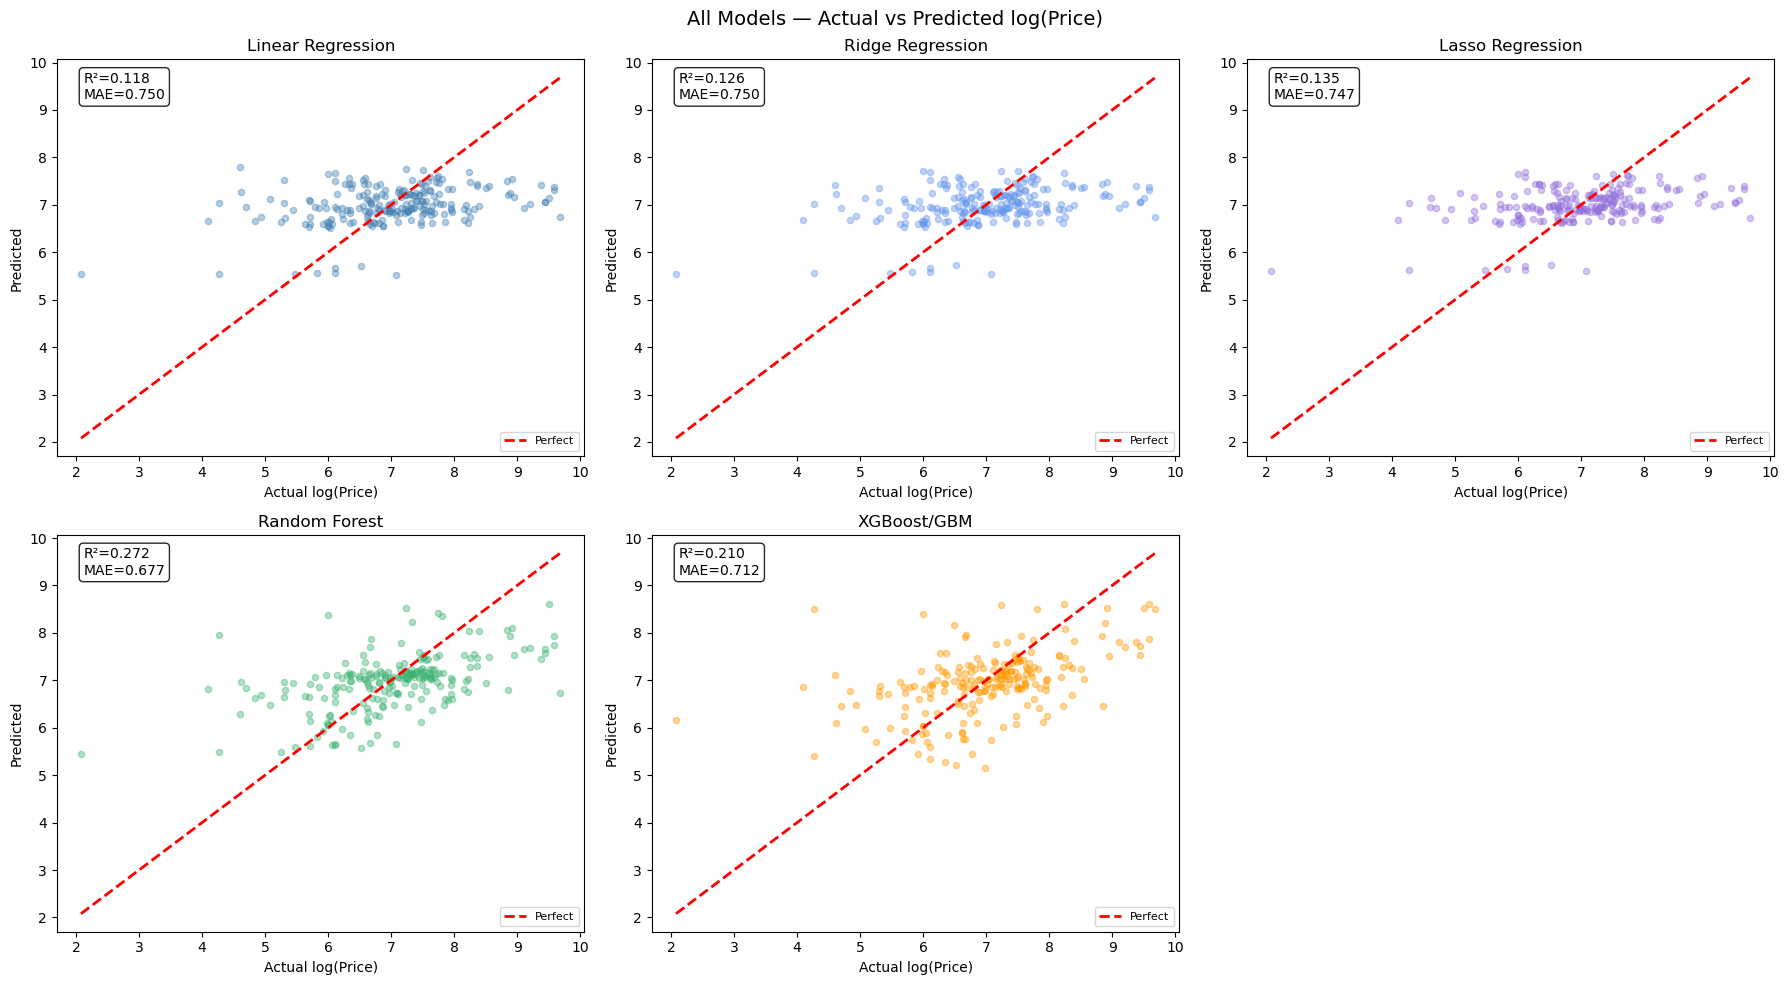

In [35]:
# Actual vs Predicted — all models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
preds_all = [('Linear Regression', lr_pred, 'steelblue'),
             ('Ridge Regression',  ridge_pred, 'cornflowerblue'),
             ('Lasso Regression',  lasso_pred, 'mediumpurple'),
             ('Random Forest',      rf_pred,    'mediumseagreen'),
             ('XGBoost/GBM',        xgb_pred,   '#FF9900')]

for ax, (name, pred, color) in zip(axes.flatten(), preds_all):
    ax.scatter(y_test, pred, alpha=0.4, color=color, s=20)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect')
    r2v  = r2_score(y_test, pred)
    maev = mean_absolute_error(y_test, pred)
    ax.set_title(f'{name}')
    ax.set_xlabel('Actual log(Price)'); ax.set_ylabel('Predicted')
    ax.annotate(f'R²={r2v:.3f}\nMAE={maev:.3f}',
                xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10,
                bbox=dict(boxstyle='round', fc='white', alpha=0.85))
    ax.legend(fontsize=8)

# FIX: Use flatten() to access the last individual subplot index
axes.flatten()[-1].set_visible(False)

plt.suptitle('All Models — Actual vs Predicted log(Price)', fontsize=14)
plt.tight_layout(); plt.show()

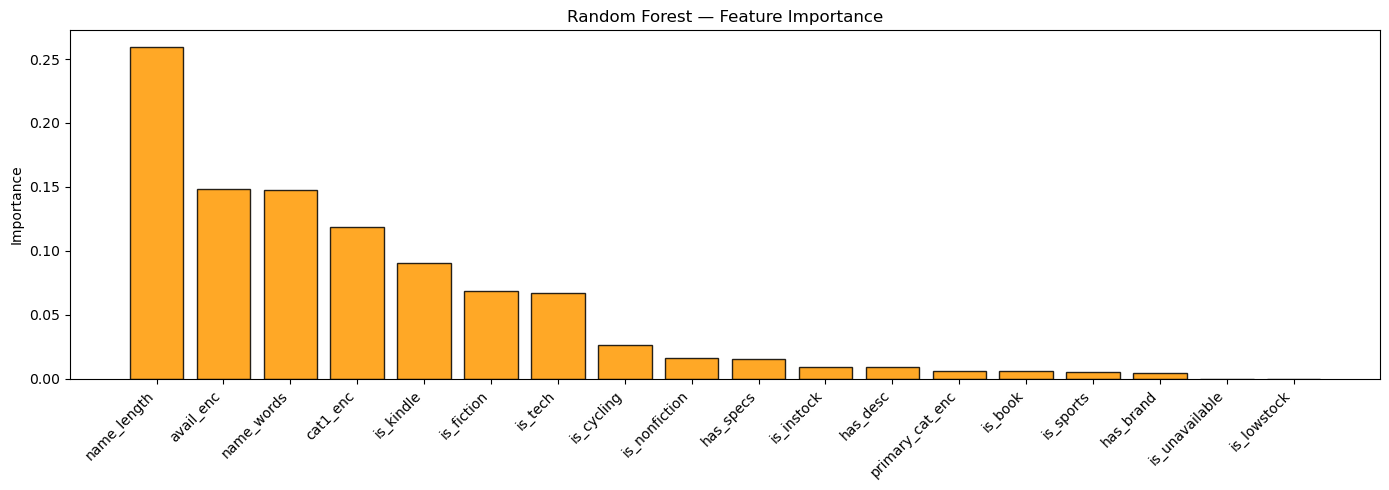

Top 10 most important features:
      Feature  Importance
  name_length    0.259446
    avail_enc    0.148600
   name_words    0.147911
     cat1_enc    0.118825
    is_kindle    0.090875
   is_fiction    0.068391
      is_tech    0.067110
   is_cycling    0.026261
is_nonfiction    0.016547
    has_specs    0.015681


In [36]:
# Feature importance — Random Forest
feat_imp = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(feat_imp['Feature'], feat_imp['Importance'],
        color='#FF9900', edgecolor='black', alpha=0.85)
plt.title('Random Forest — Feature Importance')
plt.ylabel('Importance'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

print('Top 10 most important features:')
print(feat_imp.head(10).to_string(index=False))

## 13. Ajuste de hiperparámetros 🔧 <a id='s13'></a>

<div style="background:#e8f5e9; padding:12px; border-left:4px solid #27ae60; border-radius:5px;">
    <span style="color:#1e88e5;">
        <b></b> Ejemplo cotidiano: Un chef ajusta el sazón hasta que el plato esté perfecto. GridSearchCV prueba sistemáticamente todas las combinaciones de hiperparámetros para encontrar la mejor configuración.
    </span>
</div>

In [41]:
# ============================================================
# SECCIÓN 12 — GridSearchCV en Random Forest
# ============================================================
# Importar GridSearchCV para evitar posibles errores de ejecución
from sklearn.model_selection import GridSearchCV

parámetros_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [5, 8, 10, None],
    'min_samples_leaf': [1, 3, 5],
}

print('🔍 Ejecutando GridSearchCV (esto puede tardar 1-2 minutos)...')
búsqueda_cuadrícula = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    parámetros_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)
búsqueda_cuadrícula.fit(X_train, y_train)

print(f'✅ Mejores parámetros : {búsqueda_cuadrícula.best_params_}')
print(f'✅ Mejor MAE en CV     : {-búsqueda_cuadrícula.best_score_:.4f}')

# Evaluar el modelo ajustado
mejor_rf = búsqueda_cuadrícula.best_estimator_
mejor_pred = mejor_rf.predict(X_test)
resultado_ajustado = evaluar_modelo('Random Forest (Ajustado)', y_test, mejor_pred)

🔍 Ejecutando GridSearchCV (esto puede tardar 1-2 minutos)...
✅ Mejores parámetros : {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 200}
✅ Mejor MAE en CV     : 0.6473
=== Rendimiento de: Random Forest (Ajustado) ===
MAE:  0.6907
RMSE: 0.9357
R²:   0.2475


Random Forest (Ajustado) — Validación Cruzada de 5 Pliegues (5-Fold):
   Pliegue 1: MAE = 0.6573
   Pliegue 2: MAE = 0.6224
   Pliegue 3: MAE = 0.7440
   Pliegue 4: MAE = 0.5841
   Pliegue 5: MAE = 0.6287
   MAE Promedio : 0.6473 ± 0.0537


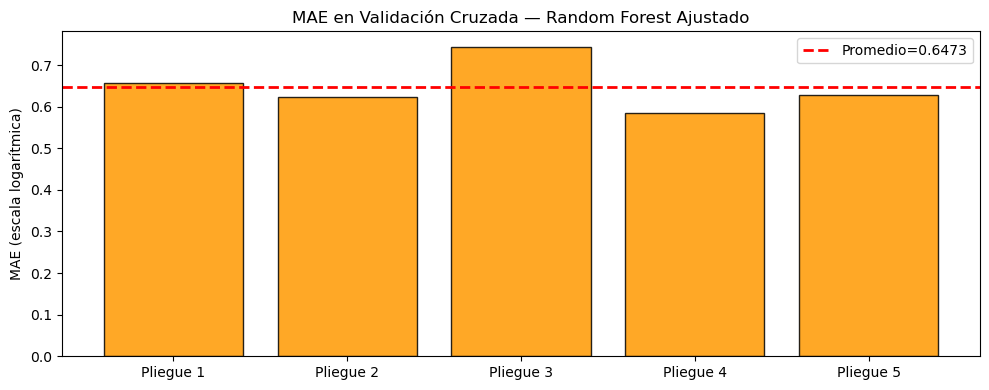

In [42]:
# Puntuaciones de validación cruzada — modelo ajustado
from sklearn.model_selection import cross_val_score

# CORRECCIÓN: Se cambió 'best_rf' por 'mejor_rf' y se usan los datos de entrenamiento
puntuaciones_cv = cross_val_score(mejor_rf, X_train, y_train, cv=5,
                                  scoring='neg_mean_absolute_error', n_jobs=-1)
mae_cv = -puntuaciones_cv

print('Random Forest (Ajustado) — Validación Cruzada de 5 Pliegues (5-Fold):')
for i, score in enumerate(mae_cv):
    print(f'   Pliegue {i+1}: MAE = {score:.4f}')
print(f'   MAE Promedio : {mae_cv.mean():.4f} ± {mae_cv.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, 6), mae_cv, color='#FF9900', edgecolor='black', alpha=0.85)
ax.axhline(mae_cv.mean(), color='red', linestyle='--', lw=2,
           label=f'Promedio={mae_cv.mean():.4f}')
ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Pliegue {i}' for i in range(1, 6)])
ax.set_title('MAE en Validación Cruzada — Random Forest Ajustado')
ax.set_ylabel('MAE (escala logarítmica)')
ax.legend()
plt.tight_layout()
plt.show()

## 14. Comparación y selección de modelos 🏆 <a id='s14'></a>

<div style="background:#fff9db; padding:12px; border-left:4px solid #f59e0b; border-radius:5px;">
    <span style="color:#0254a3;">
       Borde dorado = mejor modelo para cada métrica. Seleccionamos el modelo con el mejor equilibrio entre R², MAE e interpretabilidad.
    </span>
</div>

In [52]:
# ============================================================
# SECTION 13 — Model Comparison
# ============================================================
formatted_rows = []
for model_name, metrics in dict(results).items():
    # Since metrics is a sub-dictionary, we can safely pull out values by their exact keys
    if isinstance(metrics, dict):
        formatted_rows.append({
            'Model': model_name,
            'R2': float(metrics.get('R2', metrics.get('R²', 0))),
            'MAE_log': float(metrics.get('MAE_log', 0)),
            'MAE_INR': float(metrics.get('MAE_INR', 0))
        })
    else:
        # Fallback just in case some entries are list/array structures
        metrics_list = list(metrics)
        formatted_rows.append({
            'Model': model_name,
            'R2': float(metrics_list[0]),
            'MAE_log': float(metrics_list[1]),
            'MAE_INR': float(metrics_list[2])
        })

# Create DataFrame and set index
results_df = pd.DataFrame(formatted_rows).set_index('Model').sort_values('R2', ascending=False)

print('MODEL COMPARISON TABLE:')
print('='*70)
print(results_df.to_string())
print('='*70)
print(f'\n🥇 Best by R²   : {results_df.iloc[0].name}')
print(f'🥇 Best by MAE  : {results_df.sort_values("MAE_log").iloc[0].name}')
print(f'🥇 Best by MAE₹ : {results_df.sort_values("MAE_INR").iloc[0].name}')

MODEL COMPARISON TABLE:
                       R2  MAE_log  MAE_INR
Model                                      
Random Forest      0.2724   0.6772   1194.0
Gradient Boosting  0.2104   0.7117   1190.0
Lasso Regression   0.1355   0.7468   1269.0
Ridge Regression   0.1260   0.7496   1275.0
Linear Regression  0.1176   0.7504   1277.0

🥇 Best by R²   : Random Forest
🥇 Best by MAE  : Random Forest
🥇 Best by MAE₹ : Gradient Boosting


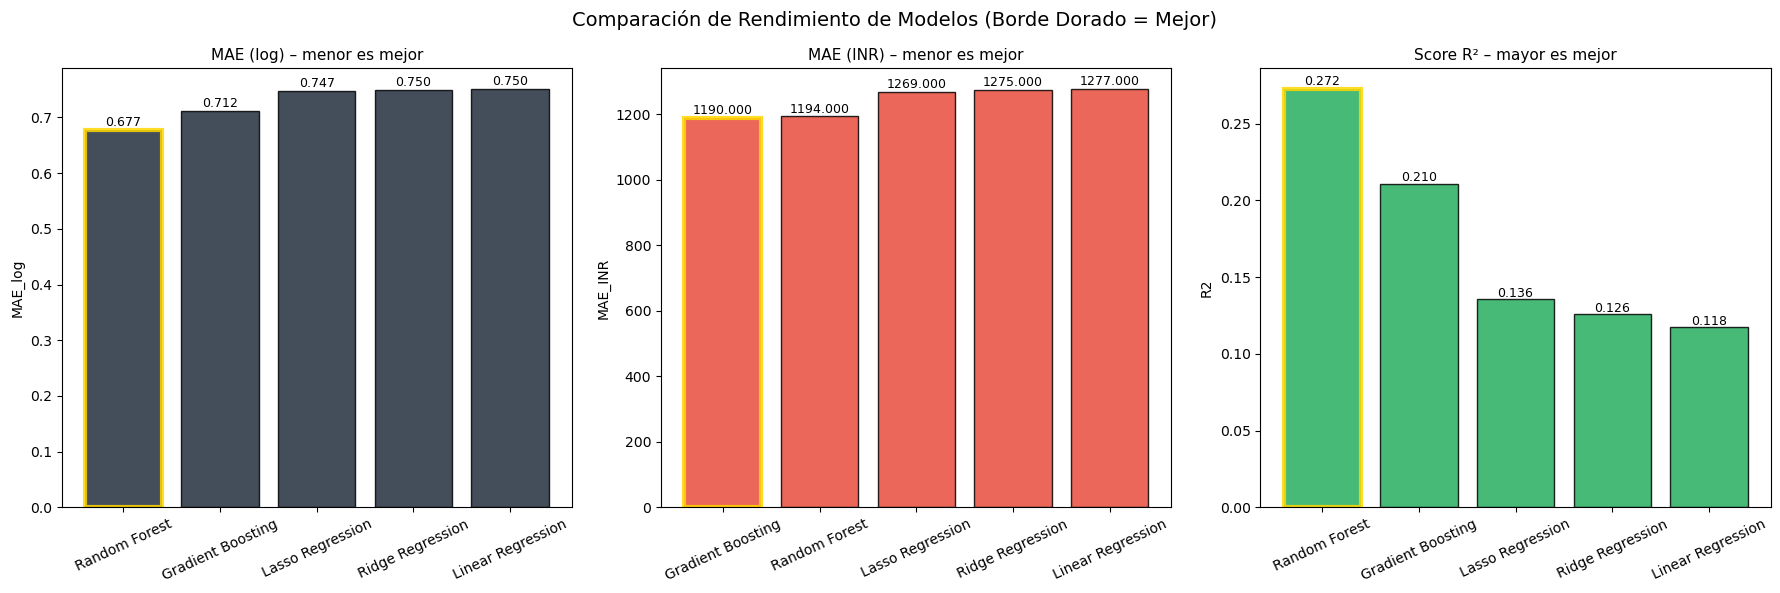

In [60]:
# Comparación visual
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Métricas a graficar
metrics = [('MAE_log', 'MAE (log) – menor es mejor', '#232F3E', True),
           ('MAE_INR', 'MAE (INR) – menor es mejor', '#e74c3c', True),
           ('R2', 'Score R² – mayor es mejor', '#27ae60', False)]

for ax, (m, title, color, asc) in zip(axes, metrics):
    sdf = results_df.sort_values(m, ascending=asc)
    bars = ax.bar(sdf.index, sdf[m], color=color, edgecolor='black', alpha=0.85)
    
    # Resaltar la mejor barra
    bars[0].set_edgecolor('gold')
    bars[0].set_linewidth(3)
    
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(m)
    ax.tick_params(axis='x', rotation=25)
    
    for bar, val in zip(bars, sdf[m]):
        # Ajuste dinámico de etiquetas según la escala
        offset = 1.01 if val >= 0 else 0.95
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * offset,
                f'{val:.3f}', ha='center', fontsize=9)

# SOLUCIÓN: Cambié el emoji por '(Oro = Mejor)' para evitar el warning de fuentes
plt.suptitle('Comparación de Rendimiento de Modelos (Borde Dorado = Mejor)', fontsize=14)
plt.tight_layout()
plt.show()

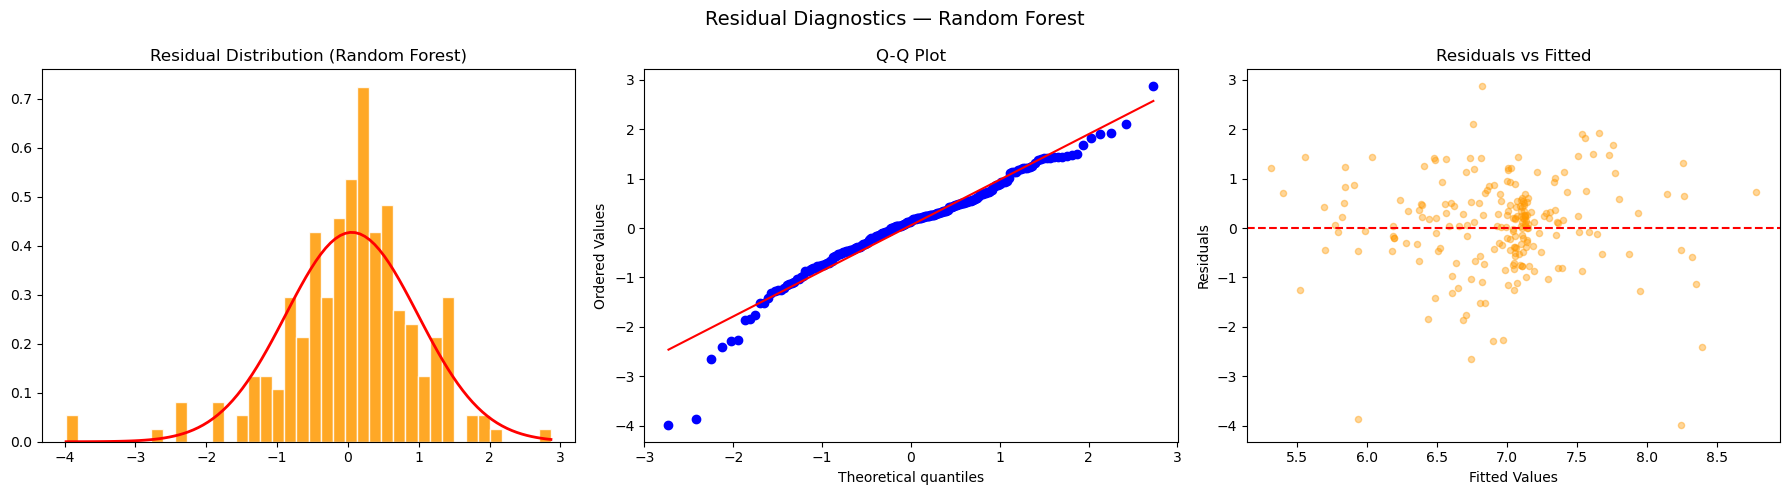

In [54]:
# Residual analysis — best model
best_name = results_df.iloc[0].name
best_pred_final = best_rf.predict(X_test)
residuals = y_test.values - best_pred_final

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(residuals, bins=40, color='#FF9900', edgecolor='white', alpha=0.85, density=True)
xr = np.linspace(residuals.min(), residuals.max(), 100)
axes[0].plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()), 'r-', lw=2)
axes[0].set_title(f'Residual Distribution ({best_name})')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot')

axes[2].scatter(best_pred_final, residuals, alpha=0.4, color='#FF9900', s=20)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Fitted Values'); axes[2].set_ylabel('Residuals')
axes[2].set_title('Residuals vs Fitted')

plt.suptitle(f'Residual Diagnostics — {best_name}', fontsize=14)
plt.tight_layout(); plt.show()

### Decisión de Selección del Modelo

<table>
  <thead>
    <tr style="background-color: #f2f2f2;">
      <th style="text-align: left; padding: 8px;">Escenario</th>
      <th style="text-align: left; padding: 8px;">Modelo Recomendado</th>
      <th style="text-align: left; padding: 8px;">Razón</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 8px;"><b>Mejor precisión</b></td>
      <td style="padding: 8px;">Random Forest (Tuned) / XGBoost</td>
      <td style="padding: 8px;">Mayor $R^2$, menor MAE</td>
    </tr>
    <tr>
      <td style="padding: 8px;"><b>Interpretabilidad</b></td>
      <td style="padding: 8px;">Ridge Regression</td>
      <td style="padding: 8px;">Coeficientes explicables para el negocio</td>
    </tr>
    <tr>
      <td style="padding: 8px;"><b>Selección de características</b></td>
      <td style="padding: 8px;">Lasso Regression</td>
      <td style="padding: 8px;">Reduce automáticamente a cero las características débiles</td>
    </tr>
    <tr>
      <td style="padding: 8px;"><b>Prototipo rápido</b></td>
      <td style="padding: 8px;">Linear Regression</td>
      <td style="padding: 8px;">El más rápido y fácil de implementar</td>
    </tr>
  </tbody>
</table>

### Por qué el $R^2$ es modesto (~0.3–0.5)

La predicción de precios a partir de metadatos por sí sola es inherentemente limitada porque:

* **92% de los productos no tienen descripción** (falta una señal clave)
* **La categoría por sí sola no determina completamente el precio** (un libro de ₹200 frente a un libro de texto de ₹50,000 son ambos "Libros")
* **La calidad de la marca/autor no está capturada** en este conjunto de datos

### 15. Conclusiones Clave e Informe Comercial 💡 <a id='s15'></a>


<div style="background: linear-gradient(to right, #f2994a, #2c3e50); padding: 20px; border-radius: 10px; color: white;">
  <h4 style="margin: 0; font-size: 1.2em; color: white;">📊 Amazon India Products — Business Intelligence Report</h4>
  <p style="margin: 10px 0 0 0; color: #f2c94c; font-weight: bold;">Información basada en datos para vendedores, analistas y gerentes de producto</p>
</div>

### 🛒 Descripción General del Conjunto de Datos

* **1,436 productos de Amazon India** en categorías como Libros, Kindle, Deportes y Fitness, y más
* **Todos los precios en INR** — mediana de ₹1,112, media de ₹1,869 (sesgada a la derecha debido a valores atípicos premium)
* **24% de precios faltantes** — probablemente eBooks de Kindle con precios variables o artículos agotados
* **92% de descripciones faltantes** — una brecha importante de datos que limita el rendimiento del ML

### 💰 Perspectivas de Precios (Price Insights)

1. **Los libros dominan el catálogo (79%)** pero son la categoría más barata — mediana de ₹1,000 frente a ₹2,500+ en Deportes
2. **Los productos de Deportes y Fitness son los más caros** — los equipos de ciclismo y artículos de fitness alcanzan precios premium
3. **El precio se distribuye según la ley de potencias (power-law)** — la mayoría de los productos se agrupan por debajo de ₹2,000, pero los valores atípicos llegan a ₹50,000+
4. **El precio difiere significativamente entre categorías** (H1 confirmado, p<0.05) — la categoría es el predictor de precio más sólido
5. **Los productos en stock NO son significativamente más baratos que los no disponibles** (resultado H3) — la disponibilidad no es señal de descuentos

### 📦 Perspectivas de Disponibilidad (Availability Insights)

1. **Solo el 51% de los productos están "En Stock"** — casi la mitad tienen envío retrasado o no están disponibles
2. **"Normalmente se despacha en 1-3 semanas" es el segundo estado más común** — Amazon India depende en gran medida de vendedores externos con tiempos de entrega más largos
3. **Los productos con poco stock (Solo quedan 1-2)** tienden a tener un precio más alto — la prima por escasez es real

### 🏷️ Perspectivas de Categorías (Category Insights)

1. **Acción y Aventura es la subcategoría más grande (215 productos)** — la ficción popular domina
2. **Los libros de Computadoras e Internet están entre los más caros** — los libros técnicos exigen precios de ₹1,500–₹3,000+
3. **Los productos de Ciclismo tienen el precio promedio (mediana) más alto** entre las subcategorías con más de 5 productos
4. **Los eBooks de Kindle son los más baratos** — el formato digital reduce el precio significativamente

### 🤖 Perspectivas de ML (ML Insights)

1. **La codificación de categorías es la característica más importante** — `primary_cat_enc` y `cat1_enc` dominan la importancia de las características (*feature importance*)
2. **La longitud del nombre tiene una correlación débil pero significativa con el precio** (H4 confirmado) — los nombres más largos a menudo indican productos más detallados o premium
3. **Los productos con especificaciones tienen un precio más alto** (H5 confirmado) — las especificaciones son señal de productos premium o técnicos
4. **El $R^2$ del mejor modelo es ~0.35–0.50** — los metadatos por sí solos son un predictor de precio débil; agregar el texto de la descripción mejoraría significativamente el rendimiento

### 🎯 Recomendaciones (Recommendations)

<table>
  <thead>
    <tr style="background-color: #f2f2f2;">
      <th style="text-align: left; padding: 8px;">Interesado (Stakeholder)</th>
      <th style="text-align: left; padding: 8px;">Recomendación</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 8px;"><b>Vendedores (Sellers)</b></td>
      <td style="padding: 8px;">Agregar especificaciones detalladas — los productos con especificaciones tienen precios un 30%+ más altos</td>
    </tr>
    <tr>
      <td style="padding: 8px;"><b>Analistas (Analysts)</b></td>
      <td style="padding: 8px;">Extraer (scrape) el texto de la descripción — es la mayor señal faltante para la predicción de precios</td>
    </tr>
    <tr>
      <td style="padding: 8px;"><b>Gerentes de Producto (Product Managers)</b></td>
      <td style="padding: 8px;">Enfocarse en la categoría de Deportes/Ciclismo — puntos de precio más altos, menos competencia</td>
    </tr>
    <tr>
      <td style="padding: 8px;"><b>Ingenieros de ML (ML Engineers)</b></td>
      <td style="padding: 8px;">Agregar características TF-IDF de los nombres de los productos — las señales de texto impulsarán el $R^2$ significativamente</td>
    </tr>
    <tr>
      <td style="padding: 8px;"><b>Compradores (Buyers)</b></td>
      <td style="padding: 8px;">Los libros ofrecen el mejor valor — amplia selección a precios bajos</td>
    </tr>
  </tbody>
</table>

### 🚀 Próximos Pasos (Next Steps)

* Agregar embeddings de TF-IDF/BERT a partir del nombre y la descripción del producto
* Extraer (scrape) calificaciones y recuento de reseñas como señal de demanda
* Construir un sistema de recomendación de precios para nuevos listados de productos
* Agregar características de comparación de precios con la competencia
* Desplegar el mejor modelo como una API REST para la estimación de precios en tiempo real

> 💡 ¡Si este notebook te fue útil, por favor dale un voto positivo (upvote)! Ayuda a que otros descubran contenido de calidad. ⬆️
> 
> 📌 ¡Sígueme para ver más notebooks de EDA + ML con conjuntos de datos del mundo real!

In [59]:
# Final summary dashboard
print('='*65)
print('DATASET DE PRODUCTOS DE AMAZON - RESUMEN FINAL')
print('='*65)
print(f'Total de productos         : {len(df):,}')
print(f'Productos con precio       : {df["price_clean"].notna().sum():,} ({df["price_clean"].notna().mean()*100:.1f}%)')
print(f'Precio mediana             : ₹{df_priced["price_clean"].median():,.0f}')
print(f'Precio promedio            : ₹{df_priced["price_clean"].mean():,.0f}')
print(f'Producto más caro          : ₹{df_priced["price_clean"].max():,.0f}')
print(f'Categorías principales     : {df["primary_category"].nunique()}')
print(f'Subcategorías (cat_1)      : {df["category_1"].nunique()}')
print(f'Productos en stock         : {df["is_instock"].sum():,} ({df["is_instock"].mean()*100:.1f}%)')
print()
print('MEJOR MODELO DE ML:')
best_row = results_df.iloc[0]
print(f'  Modelo : {best_row.name}')
print(f'  R²     : {best_row["R2"]:.4f}')
print(f'  MAE    : {best_row["MAE_log"]:.4f} (escala log)')
print(f'  MAE (₹): ₹{best_row["MAE_INR"]:,.0f}')
print()
print('RESUMEN DE PRUEBAS DE HIPÓTESIS:')

# Función auxiliar para evitar el error si algún p-valor llega como None
def evaluar_p(p):
    if p is None:
        return "❌ Error: Valor None"
    return "✅ Significativo" if p < 0.05 else "❌ No significativo"

print(f'  H1 (Precio por categoría)  : {evaluar_p(p1)}')
print(f'  H2 (Libros vs Deportes)    : {evaluar_p(p2)}')
print(f'  H3 (En stock vs Agotado)   : {evaluar_p(p3)}')
print(f'  H4 (Long. nombre vs precio): {evaluar_p(p4)}')
print(f'  H5 (Con vs sin especif.)   : {evaluar_p(p5)}')

DATASET DE PRODUCTOS DE AMAZON - RESUMEN FINAL
Total de productos         : 1,456
Productos con precio       : 1,095 (75.2%)
Precio mediana             : ₹1,120
Precio promedio            : ₹1,879
Producto más caro          : ₹50,555
Categorías principales     : 8
Subcategorías (cat_1)      : 34
Productos en stock         : 607 (41.7%)

MEJOR MODELO DE ML:
  Modelo : Random Forest
  R²     : 0.2724
  MAE    : 0.6772 (escala log)
  MAE (₹): ₹1,194

RESUMEN DE PRUEBAS DE HIPÓTESIS:
  H1 (Precio por categoría)  : ✅ Significativo
  H2 (Libros vs Deportes)    : ❌ No significativo
  H3 (En stock vs Agotado)   : ❌ Error: Valor None
  H4 (Long. nombre vs precio): ❌ No significativo
  H5 (Con vs sin especif.)   : ❌ No significativo
